# BG7 -- SOTA analytics notebook

Self-contained companion to `metrics/metrics_tables.html`. **All figures
render inline** -- no PNG/PDF side-files, no external assets. Re-run
end-to-end from a fresh clone after the v4 pipeline has finished.

Sections:

1. Setup -- imports, paths, helpers, defensive loaders.
2. Embedding-space geography -- UMAPs of raw scGPT, cAE, and (if
   available) the supervised-fine-tuned scGPT, side by side and
   coloured by cohort to read batch-correction quality off the page.
3. Clinical biology overlays -- the cAE UMAP coloured by clinical
   covariates and Kassandra cell fractions.
4. Survival biology -- stratified Kaplan-Meier curves with log-rank.
5. Model interpretability -- SHAP global + dependence and the
   gain-based XGBoost ranking that complements it.
6. OOD generalization -- ROC and PR per public PUB cohort for the
   best classifier trained on the TRAIN pool.
7. Leaderboard + diagnostics -- C-index by feature combination,
   per-fold spread, embedding L2-norm density, predicted-risk UMAP.

Every figure carries the underlying sample size and, where applicable,
the metric value in its title.

## 1. Setup

In [1]:
"""Imports, paths, and defensive loaders. Skip-on-missing throughout."""
from __future__ import annotations

import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# --- Plot styling: large, legible, presentation-grade --------------------
plt.rcParams.update({
    "figure.figsize": (12, 7),
    "figure.dpi": 110,
    "savefig.dpi": 140,
    "font.size": 14,
    "axes.titlesize": 17,
    "axes.titleweight": "bold",
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 1.1,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linewidth": 0.7,
})
sns.set_palette("tab10")

# --- Paths ---------------------------------------------------------------
NB_DIR = Path.cwd()
REPO_ROOT = NB_DIR.parent if NB_DIR.name == "visualizations" else NB_DIR
PROCESSED = REPO_ROOT / "data" / "processed"
METRICS_CSV = REPO_ROOT / "metrics_csv"
EMB_DIR = REPO_ROOT / "embeddings"

TRAIN_H5AD = PROCESSED / "TRAIN_Combined_cAE_Corrected.h5ad"
PUB_PATHS = {
    "PUB_BLCA":      PROCESSED / "PUB_BLCA_Mariathasan_EGAS00001002556_ICI.h5ad",
    "PUB_ccRCC_ICI": PROCESSED / "PUB_ccRCC_Immotion150_and_151_ICI.h5ad",
    "PUB_ccRCC_TKI": PROCESSED / "PUB_ccRCC_Immotion150_and_151_TKI.h5ad",
}

# --- obsm key contract ---------------------------------------------------
RAW_KEY      = "scGPT_embedding"
CAE_KEY      = "cAE_embedding"
CAE_OOD_KEY  = "cAE_embedding_OOD"
FT_KEY       = "scGPT_finetuned_embedding"  # written by finetune_scgpt_survival.py


def safe_load(path: Path):
    if not path.exists():
        return None
    return sc.read_h5ad(str(path))


def first_col(df: pd.DataFrame, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None


def n_valid(arr: np.ndarray) -> int:
    """How many rows of an obsm matrix have no NaN."""
    if arr is None:
        return 0
    return int((~np.isnan(arr).any(axis=1)).sum())


train = safe_load(TRAIN_H5AD)
pubs = {n: safe_load(p) for n, p in PUB_PATHS.items()}

print("REPO     :", REPO_ROOT)
if train is not None:
    print(f"TRAIN    : n={train.n_obs:,}  vars={train.n_vars:,}  "
          f"obsm keys={sorted(train.obsm.keys())}")
for name, ad in pubs.items():
    if ad is not None:
        print(f"{name:14s}: n={ad.n_obs:,}")

ft_present = train is not None and FT_KEY in train.obsm and n_valid(
    np.asarray(train.obsm[FT_KEY])
) >= int(0.5 * train.n_obs)
print()
print("Fine-tuned scGPT embedding (full coverage):", ft_present)


C:\Users\Gevorg\Desktop\bg7\batchcor-rna-embeds\batcor_env\Lib\site-packages\scanpy\_utils\__init__.py:27: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version


C:\Users\Gevorg\Desktop\bg7\batchcor-rna-embeds\batcor_env\Lib\site-packages\scanpy\__init__.py:36: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
C:\Users\Gevorg\Desktop\bg7\batchcor-rna-embeds\batcor_env\Lib\site-packages\scanpy\readwrite.py:15: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):


REPO     : C:\Users\Gevorg\Desktop\bg7\batchcor-rna-embeds
TRAIN    : n=2,027  vars=20,062  obsm keys=['PCA128d_cAE_embedding', 'PCA128d_scGPT_embedding', 'UMAP3d_cAE_embedding', 'UMAP3d_scGPT_embedding', 'cAE_embedding', 'scGPT_embedding', 'scGPT_finetuned_embedding']
PUB_BLCA      : n=347
PUB_ccRCC_ICI : n=560
PUB_ccRCC_TKI : n=486

Fine-tuned scGPT embedding (full coverage): False


## 2. Embedding-space geography

The first thing to ask of any batch-corrected embedding is whether the
cohort signal has actually been mixed out. Below: UMAPs of the raw
scGPT vector, the cAE-corrected vector, and (if a fine-tuned scGPT
embedding is on disk) the supervised-fine-tuned vector. All three
share the same patient set; the only thing that changes is the
embedding.

In [2]:
"""Compute one UMAP per available embedding (cached in adata.obsm)."""
import umap

def get_umap(ad, emb_key, cache_key, n_neighbors=20, min_dist=0.30, seed=42):
    if cache_key in ad.obsm:
        return np.asarray(ad.obsm[cache_key])
    if emb_key not in ad.obsm:
        return None
    emb = np.asarray(ad.obsm[emb_key])
    valid = ~np.isnan(emb).any(axis=1)
    out = np.full((emb.shape[0], 2), np.nan, dtype=np.float32)
    if valid.sum() < 10:
        return None
    reducer = umap.UMAP(
        n_neighbors=n_neighbors, min_dist=min_dist,
        n_components=2, random_state=seed, metric="euclidean",
    )
    out[valid] = reducer.fit_transform(emb[valid]).astype(np.float32)
    ad.obsm[cache_key] = out
    return out

UMAP_RAW = get_umap(train, RAW_KEY, "umap2d_raw_scgpt")
UMAP_CAE = get_umap(train, CAE_KEY, "umap2d_cae")
UMAP_FT  = get_umap(train, FT_KEY, "umap2d_ft_scgpt") if ft_present else None

print("raw UMAP:", None if UMAP_RAW is None else UMAP_RAW.shape,
      "| cAE UMAP:", None if UMAP_CAE is None else UMAP_CAE.shape,
      "| FT UMAP:", None if UMAP_FT is None else UMAP_FT.shape)


C:\Users\Gevorg\Desktop\bg7\batchcor-rna-embeds\batcor_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


raw UMAP: (2027, 2) | cAE UMAP: (2027, 2) | FT UMAP: None


### 2.1  Side-by-side UMAPs coloured by cohort

If the correction worked, the colours that look pulled apart in the
raw panel should overlap in the cAE / FT panels. The exact opposite
of "Simpson's paradox" applied to RNA batches.

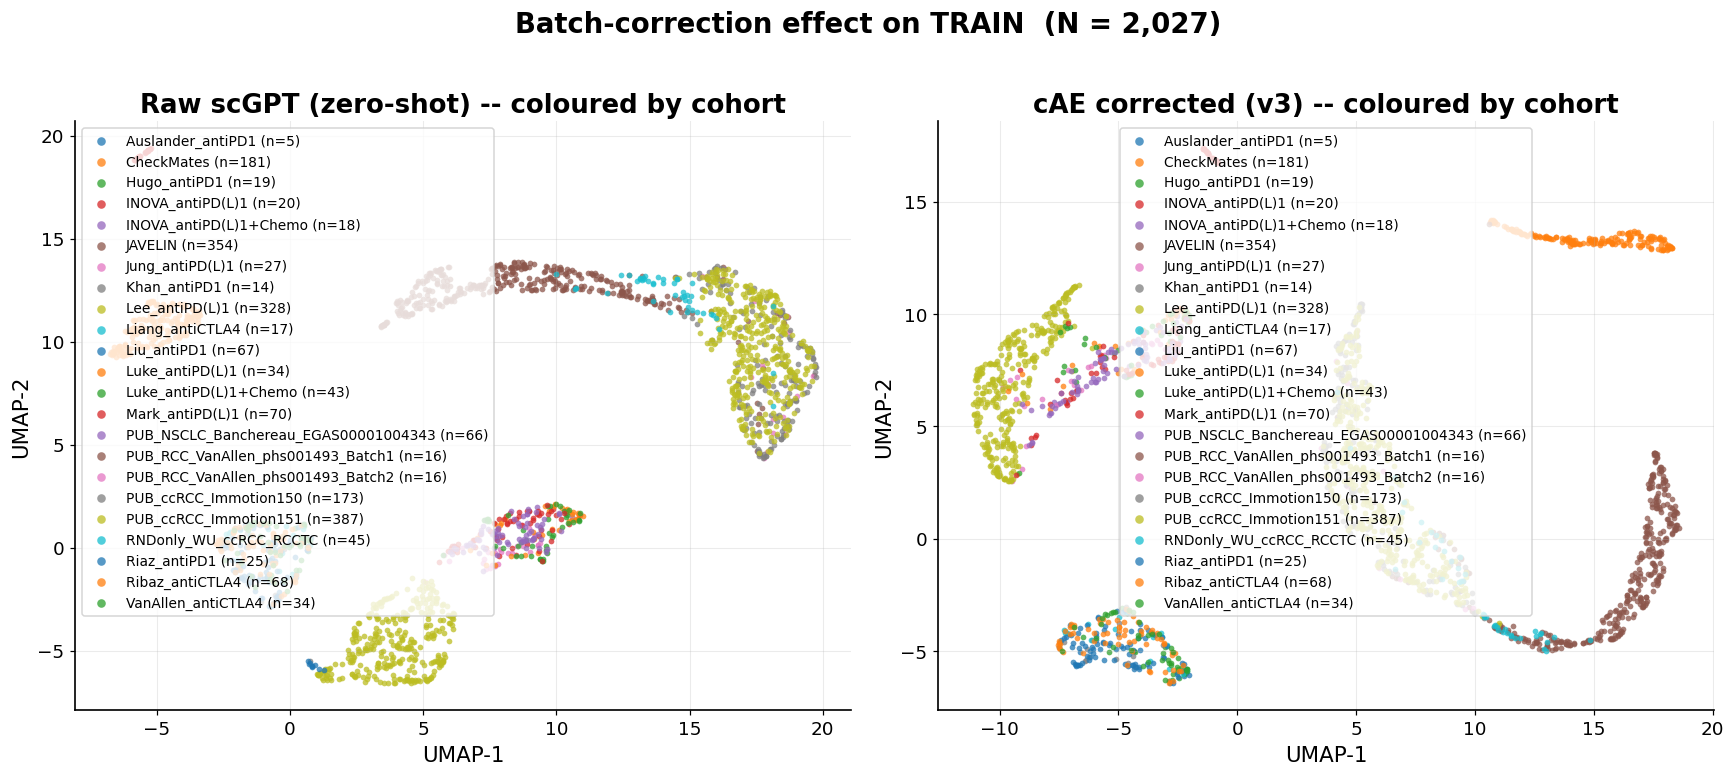

In [3]:
def _scatter_by_cat(ax, xy, labels, title, palette=None, alpha=0.75, s=14):
    ax.set_title(title)
    if xy is None:
        ax.text(0.5, 0.5, "(embedding not available)",
                ha="center", va="center", transform=ax.transAxes,
                fontsize=14, color="#666")
        ax.set_xticks([]); ax.set_yticks([])
        return
    cats = pd.Series(labels).astype(str)
    uniq = sorted(cats.dropna().unique())
    palette = palette or sns.color_palette("tab10", len(uniq))
    for i, cat in enumerate(uniq):
        mask = (cats == cat).values & ~np.isnan(xy).any(axis=1)
        ax.scatter(xy[mask, 0], xy[mask, 1],
                   s=s, alpha=alpha, c=[palette[i % len(palette)]],
                   label=f"{cat} (n={int(mask.sum())})", linewidths=0)
    ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2")
    ax.legend(loc="best", frameon=True, fontsize=9, markerscale=1.5)

cohort = train.obs["Cohort"].astype(str) if "Cohort" in train.obs else pd.Series(["?"] * train.n_obs)

n_panels = 3 if UMAP_FT is not None else 2
fig, axes = plt.subplots(1, n_panels, figsize=(8 * n_panels, 7), sharex=False, sharey=False)
axes = np.atleast_1d(axes)

_scatter_by_cat(axes[0], UMAP_RAW, cohort, "Raw scGPT (zero-shot) -- coloured by cohort")
_scatter_by_cat(axes[1], UMAP_CAE, cohort, "cAE corrected (v3) -- coloured by cohort")
if UMAP_FT is not None:
    _scatter_by_cat(axes[2], UMAP_FT, cohort, "Fine-tuned scGPT -- coloured by cohort")

fig.suptitle(f"Batch-correction effect on TRAIN  (N = {train.n_obs:,})",
             fontsize=18, fontweight="bold", y=1.01)
fig.tight_layout()
plt.show()


### 2.2  Same UMAPs, coloured by Diagnosis

Diagnosis is a *desired* signal -- batch correction should preserve
it. If diagnosis-specific clusters survive in the corrected panel, the
biology has not been thrown out with the bath water.

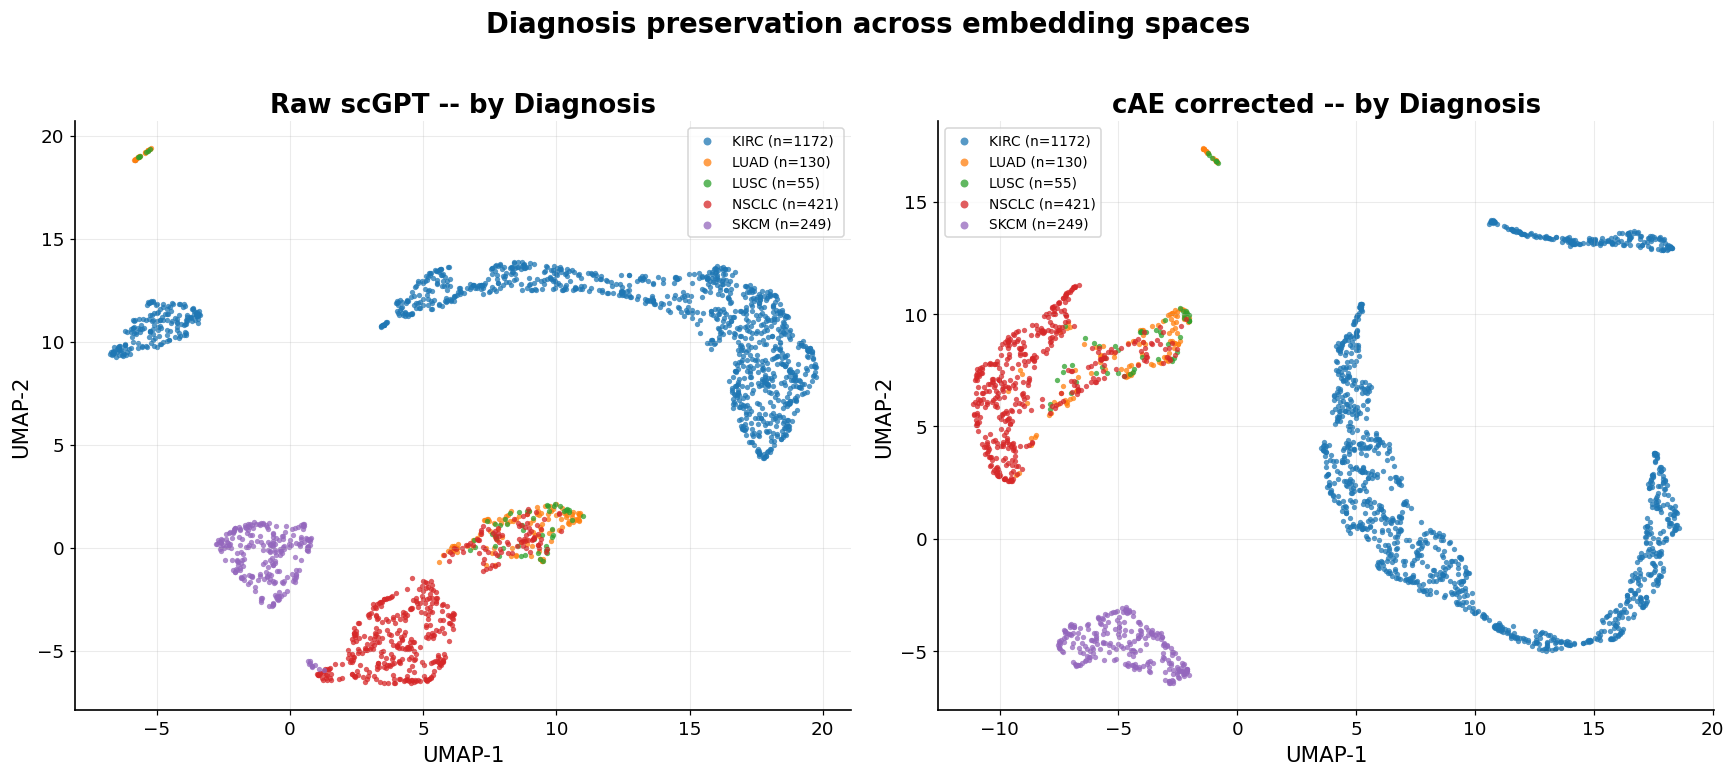

In [4]:
diag_col = first_col(train.obs, ["Diagnosis", "DIAGNOSIS", "Tumor_type", "tumor_type"])
diag = train.obs[diag_col].astype(str) if diag_col else pd.Series(["?"] * train.n_obs)

n_panels = 3 if UMAP_FT is not None else 2
fig, axes = plt.subplots(1, n_panels, figsize=(8 * n_panels, 7))
axes = np.atleast_1d(axes)

_scatter_by_cat(axes[0], UMAP_RAW, diag, f"Raw scGPT -- by {diag_col}", s=12)
_scatter_by_cat(axes[1], UMAP_CAE, diag, f"cAE corrected -- by {diag_col}", s=12)
if UMAP_FT is not None:
    _scatter_by_cat(axes[2], UMAP_FT, diag, f"Fine-tuned scGPT -- by {diag_col}", s=12)

fig.suptitle("Diagnosis preservation across embedding spaces", fontsize=18, fontweight="bold", y=1.01)
fig.tight_layout()
plt.show()


### 2.3  L2-norm density per embedding

A health-check on the embedding: if one space has a huge norm
distribution it means a few coordinates dominate (bad for downstream
linear models). Tight, near-Gaussian densities are good.

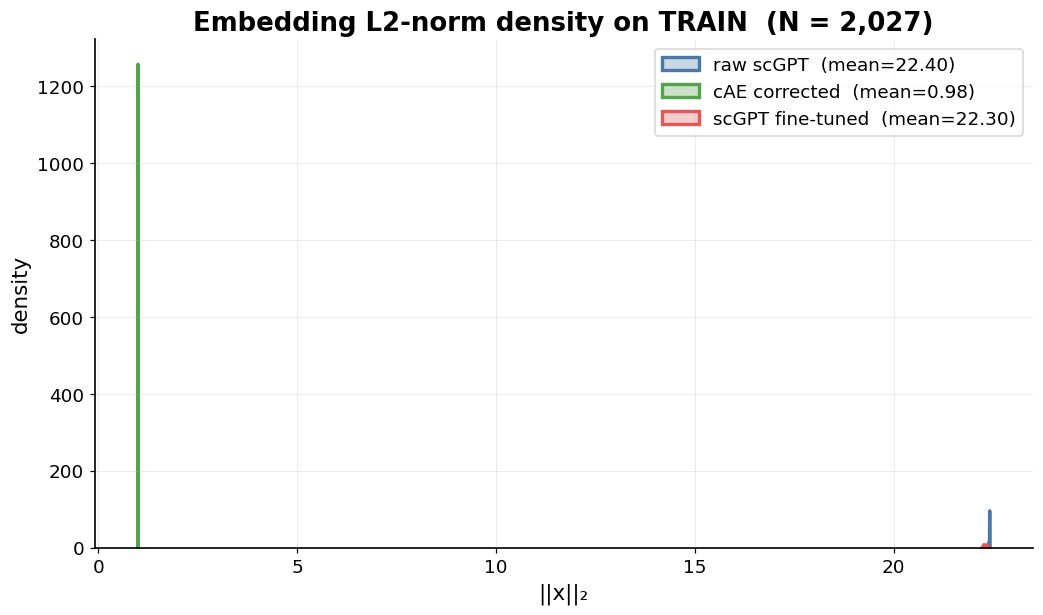

In [5]:
fig, ax = plt.subplots(figsize=(11, 6))
plotted = 0
for key, label, color in [
    (RAW_KEY, "raw scGPT",        "#4C78A8"),
    (CAE_KEY, "cAE corrected",    "#54A24B"),
    (FT_KEY,  "scGPT fine-tuned", "#E45756"),
]:
    if key in train.obsm:
        emb = np.asarray(train.obsm[key])
        emb = emb[~np.isnan(emb).any(axis=1)]
        if emb.shape[0] < 5:
            continue
        norms = np.linalg.norm(emb, axis=1)
        sns.kdeplot(norms, ax=ax, label=f"{label}  (mean={norms.mean():.2f})",
                    fill=True, alpha=0.30, lw=2.2, color=color)
        plotted += 1
ax.set_title(f"Embedding L2-norm density on TRAIN  (N = {train.n_obs:,})")
ax.set_xlabel("||x||₂");  ax.set_ylabel("density")
if plotted: ax.legend(frameon=True)
plt.show()


## 3. Clinical biology overlays on the cAE UMAP

The cAE space is the one we benchmark the most, so all subsequent
overlays use it. Each panel keeps the same XY but recolours by a
different signal so you can read which axis carries which biology.

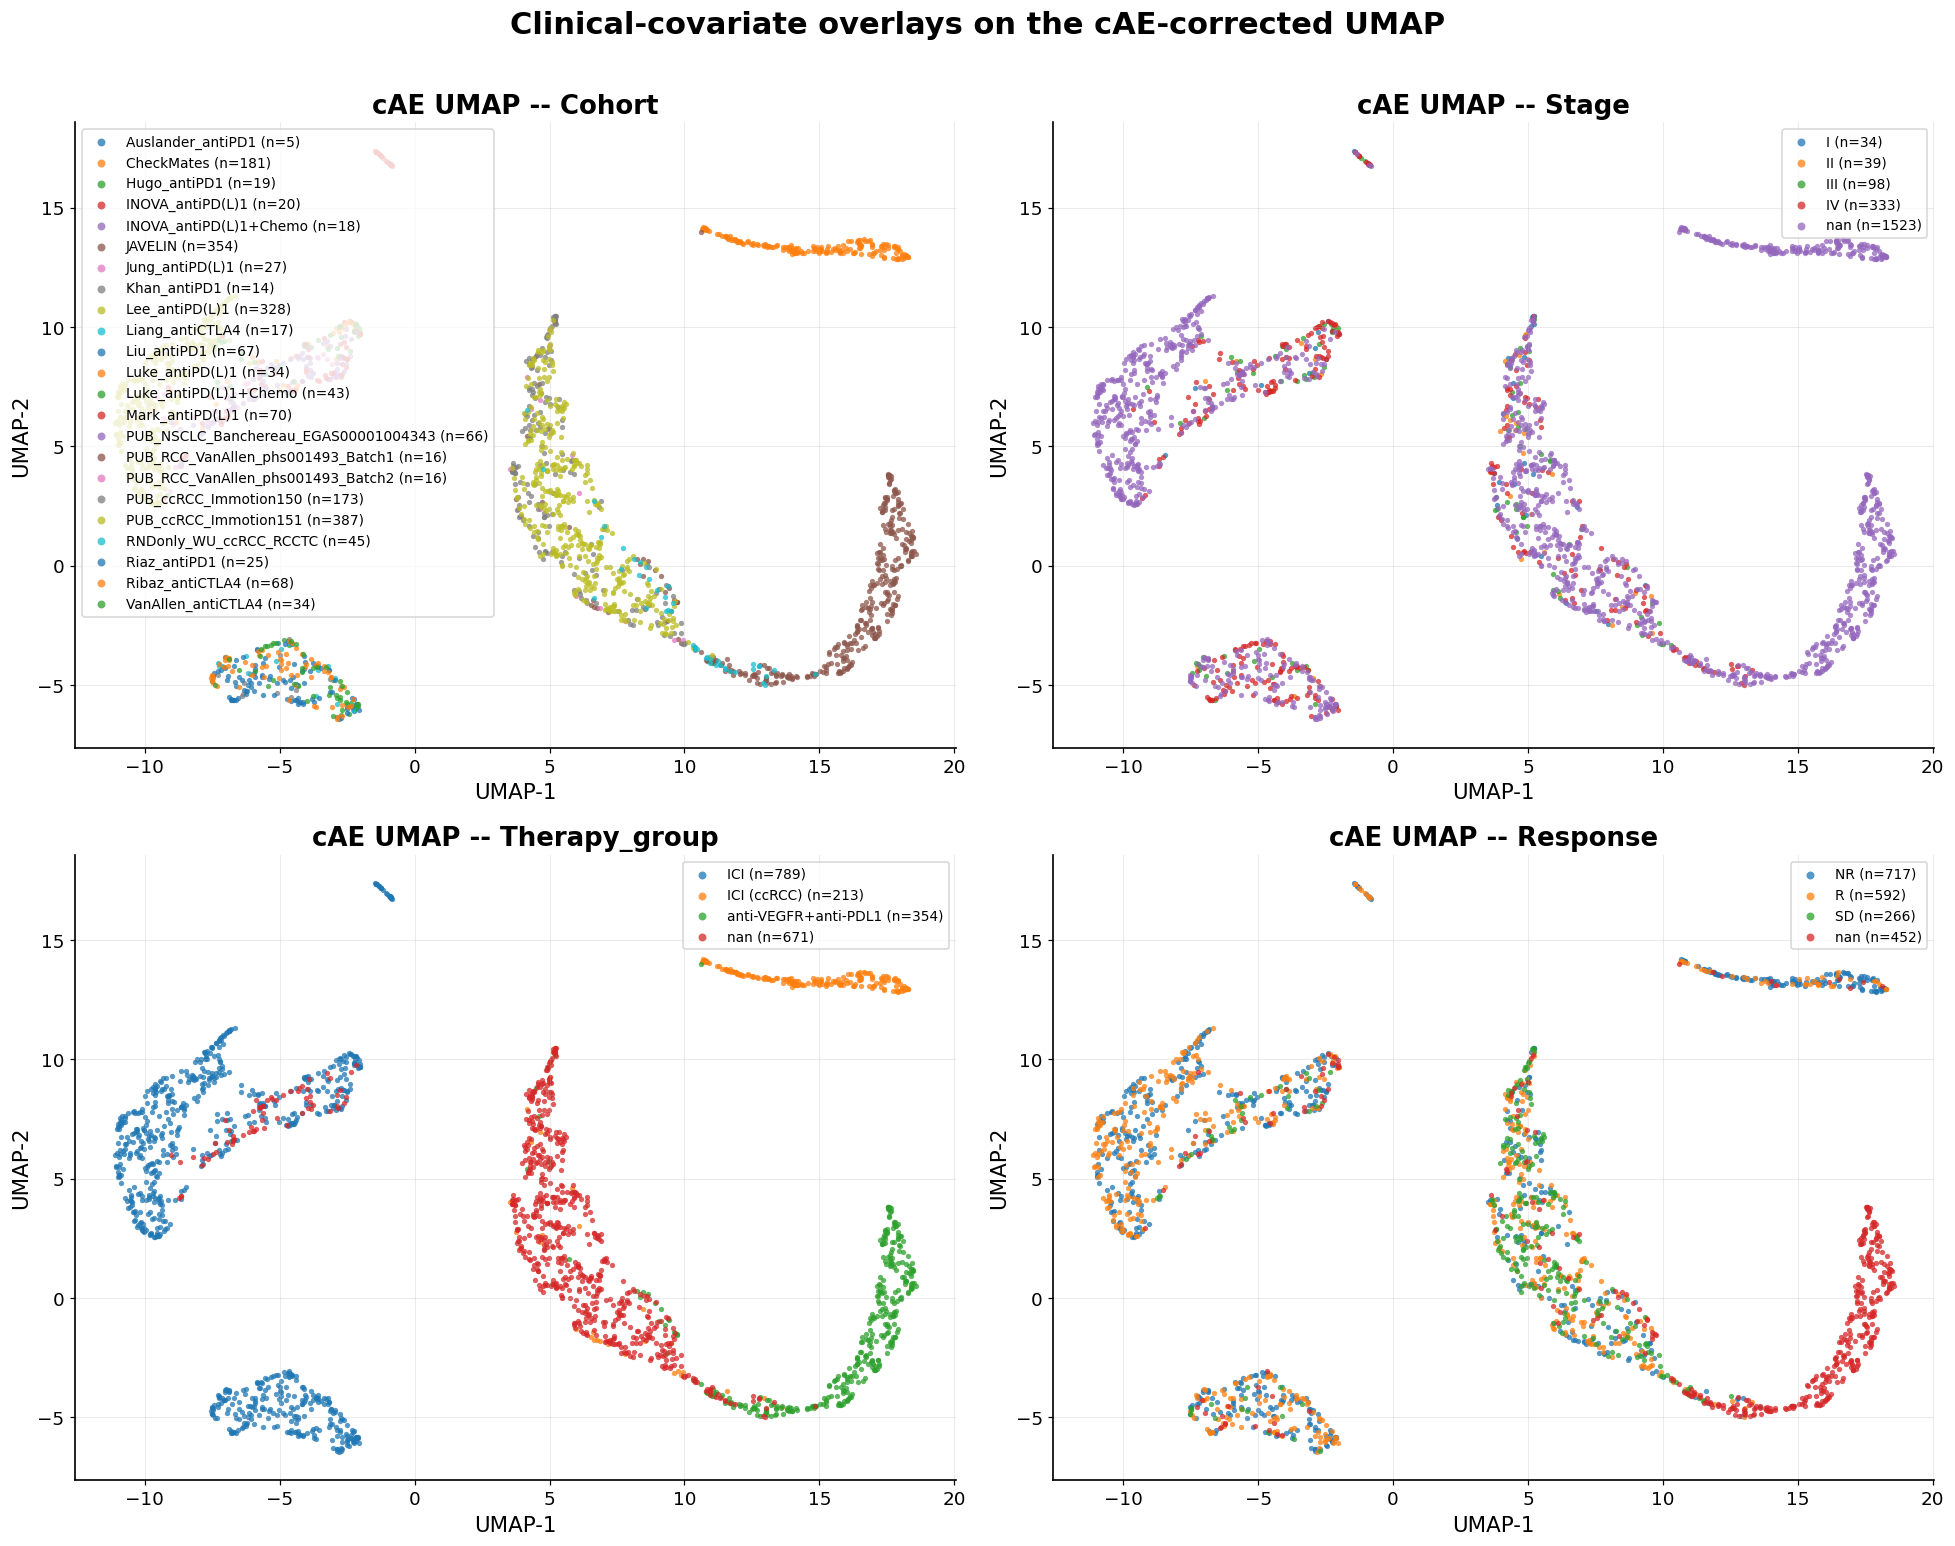

In [6]:
"""4-panel categorical overlay on cAE UMAP."""
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

panels = [
    ("Cohort",   ["Cohort", "Dataset_ID"]),
    ("Stage",    ["Stage", "STAGE", "TumorStage"]),
    ("Therapy",  ["Therapy_group", "Therapy", "treatment", "Treatment"]),
    ("Response", ["Response", "Response_binary", "RECIST"]),
]

for ax, (name, candidates) in zip(axes.flat, panels):
    col = first_col(train.obs, candidates)
    if col is None or UMAP_CAE is None:
        ax.text(0.5, 0.5, f"(no {name} column)", ha="center", va="center",
                transform=ax.transAxes, fontsize=14)
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_title(name)
        continue
    _scatter_by_cat(ax, UMAP_CAE, train.obs[col].astype(str),
                    f"cAE UMAP -- {col}", s=12)

fig.suptitle("Clinical-covariate overlays on the cAE-corrected UMAP",
             fontsize=20, fontweight="bold", y=1.005)
fig.tight_layout()
plt.show()


### 3.1  Top-4 Kassandra cell fractions on the cAE UMAP

Cancer is, in part, an immune-stromal-tumour composition problem.
Colouring the embedding by the deconvolved cell fractions tells us
which patches of the manifold are tumour-dense vs immune-infiltrated.
We show the top-4 by variance, since high-variance fractions are the
ones that actually move across the cohort.

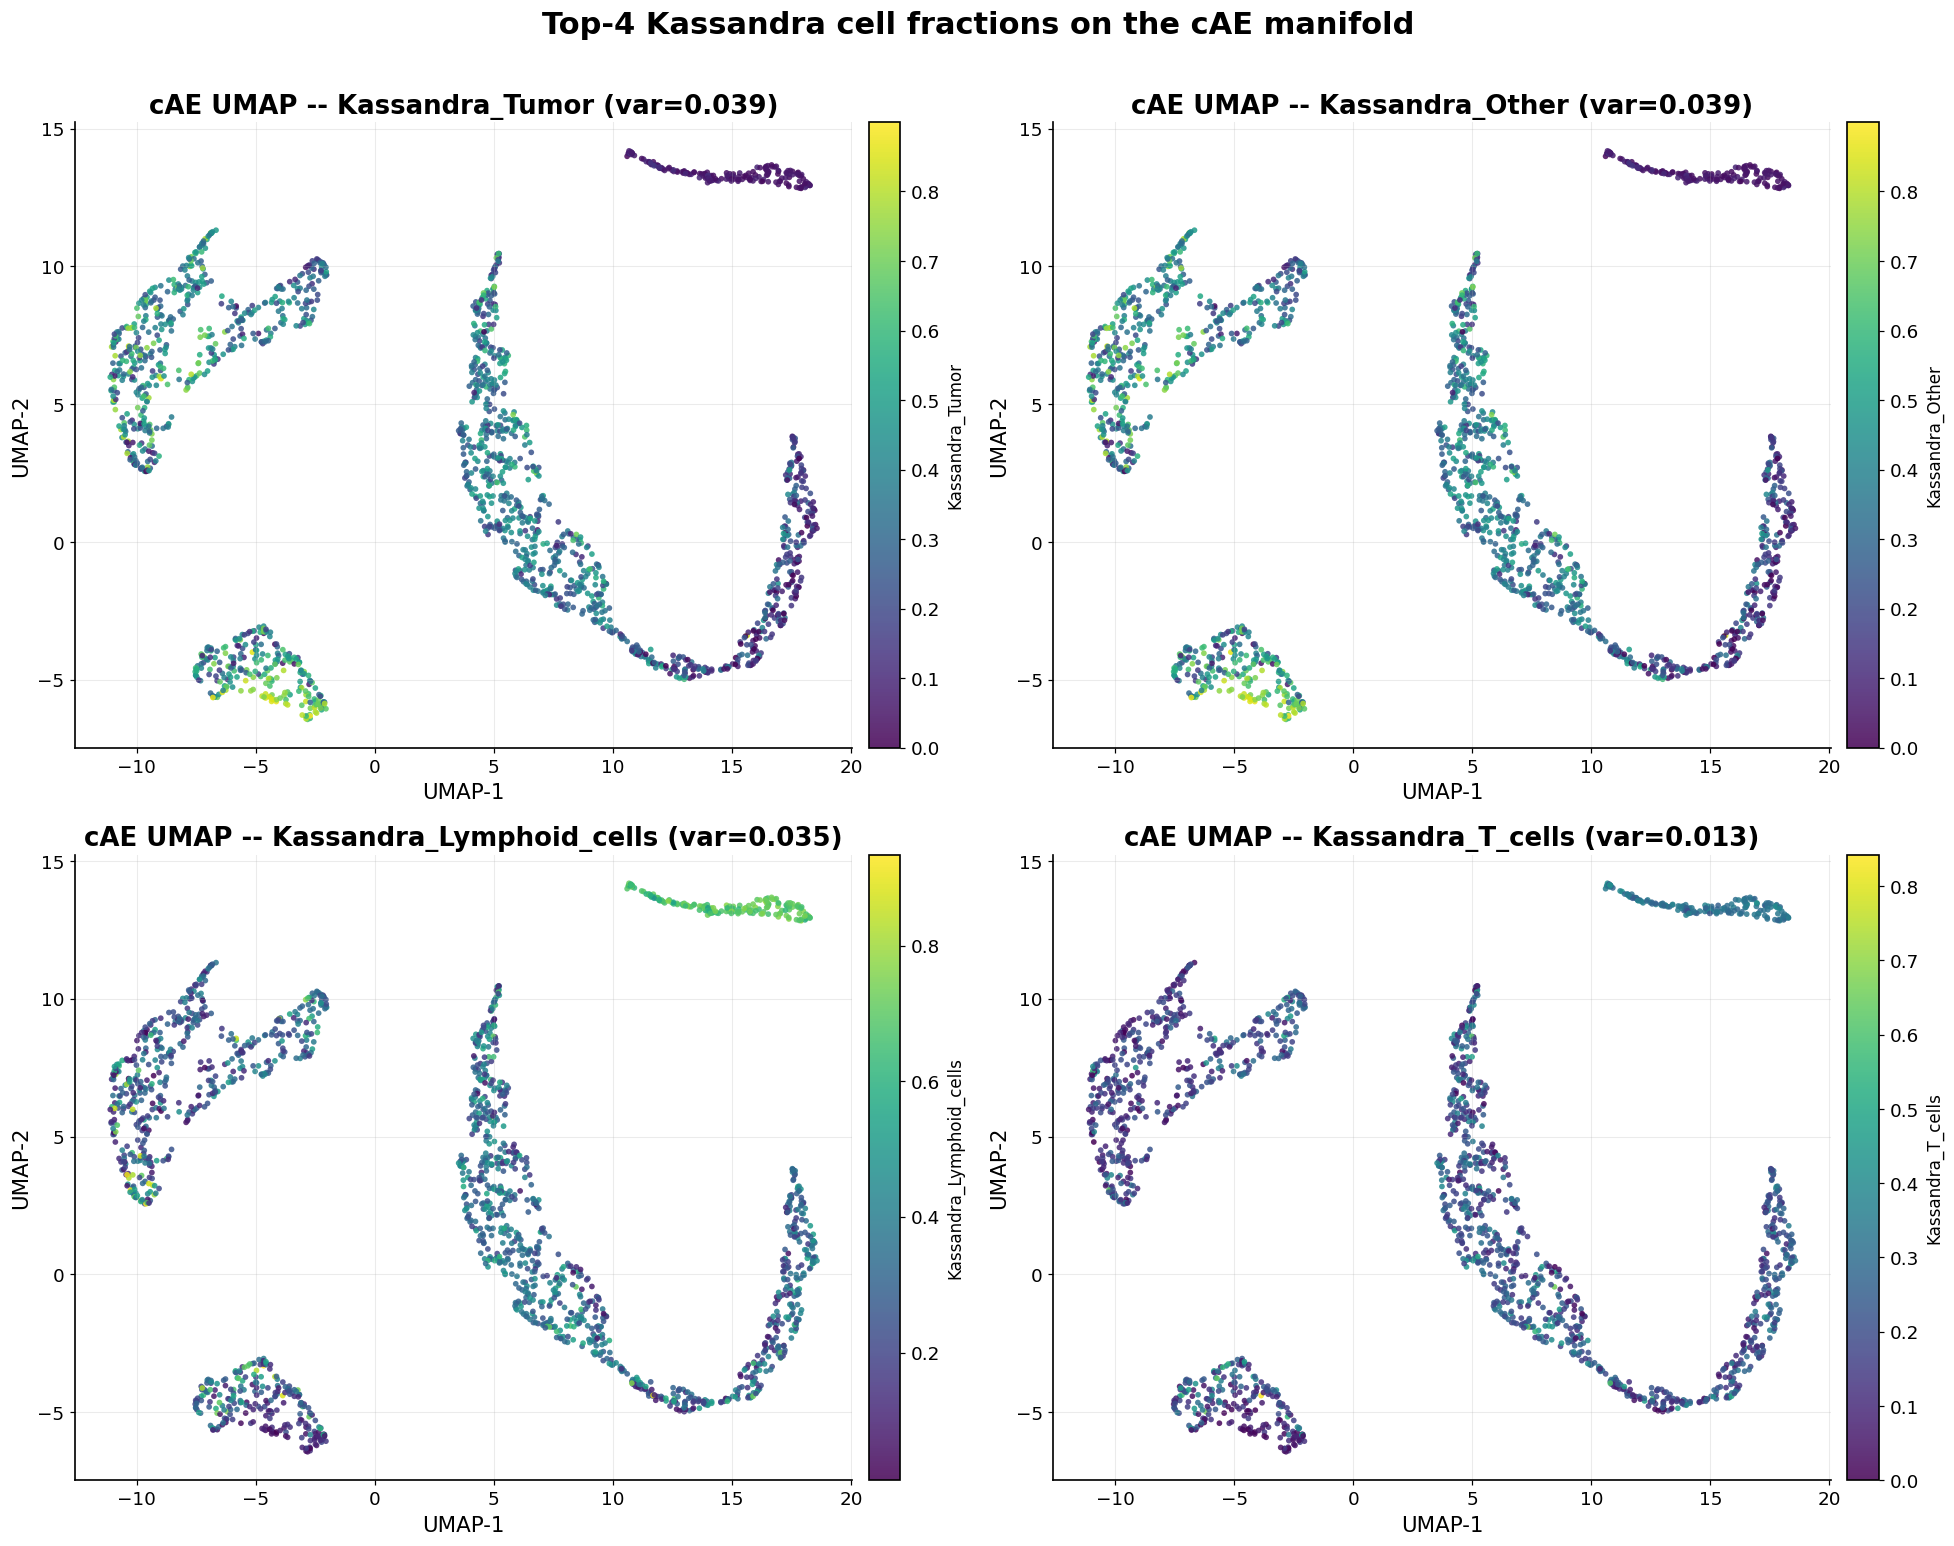

In [7]:
kass_cols = [c for c in train.obs.columns if c.startswith("Kassandra")]
if kass_cols and UMAP_CAE is not None:
    obs_num = train.obs[kass_cols].apply(pd.to_numeric, errors="coerce")
    top4 = obs_num.var(numeric_only=True).sort_values(ascending=False).head(4).index.tolist()

    fig, axes = plt.subplots(2, 2, figsize=(18, 14))
    for ax, col in zip(axes.flat, top4):
        vals = pd.to_numeric(train.obs[col], errors="coerce").to_numpy()
        valid = ~np.isnan(vals) & ~np.isnan(UMAP_CAE).any(axis=1)
        sc1 = ax.scatter(UMAP_CAE[valid, 0], UMAP_CAE[valid, 1],
                         c=vals[valid], cmap="viridis", s=14,
                         alpha=0.85, linewidths=0)
        ax.set_title(f"cAE UMAP -- {col} (var={obs_num[col].var():.2g})")
        ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2")
        cb = fig.colorbar(sc1, ax=ax, fraction=0.045, pad=0.02)
        cb.set_label(col, fontsize=11)

    fig.suptitle("Top-4 Kassandra cell fractions on the cAE manifold",
                 fontsize=20, fontweight="bold", y=1.005)
    fig.tight_layout()
    plt.show()
else:
    print("(no Kassandra columns or no cAE UMAP -- skipping)")


### 3.2  Correlation cluster-map: top cAE dims vs clinical features

Each row is one of the top-10 cAE latent dimensions (by variance);
each column is a clinical feature. Hierarchical clustering on both
axes makes it easy to see which dimensions specialise in which
biology (e.g. "dim-3 is the tumour purity axis").

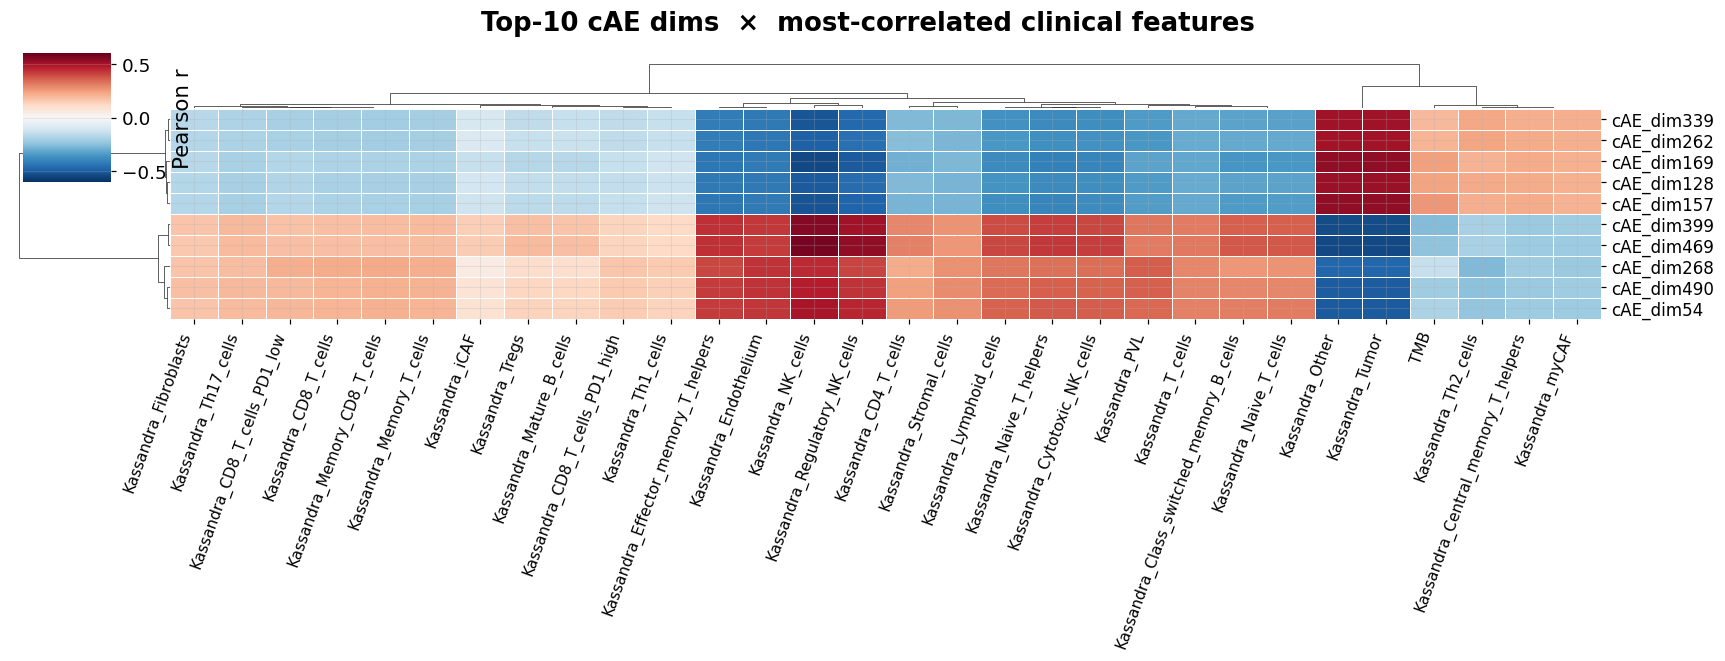

In [8]:
"""Pearson correlation, |corr| top-30 clinical features for legibility."""
if CAE_KEY in train.obsm and UMAP_CAE is not None:
    cae = np.asarray(train.obsm[CAE_KEY])
    var_top10 = np.argsort(cae.var(axis=0))[::-1][:10]
    cae_df = pd.DataFrame(cae[:, var_top10],
                          columns=[f"cAE_dim{i}" for i in var_top10])
    clin_cols = (
        [c for c in train.obs.columns if c.startswith("Kassandra")]
        + [c for c in train.obs.columns if c.startswith("MFP")]
        + [c for c in ("Age", "TMB", "PDL1") if c in train.obs.columns]
    )
    clin = train.obs[clin_cols].apply(pd.to_numeric, errors="coerce").reset_index(drop=True)
    valid = (~clin.isna().all(axis=0)).values
    clin = clin.loc[:, valid]
    corr = pd.concat([cae_df.reset_index(drop=True), clin], axis=1).corr().loc[
        cae_df.columns, clin.columns
    ]
    abs_max = corr.abs().max(axis=0).sort_values(ascending=False).head(30).index
    sub = corr[abs_max]
    g = sns.clustermap(sub, cmap="RdBu_r", center=0, vmin=-0.6, vmax=0.6,
                       figsize=(16, 6.5), linewidths=0.4, linecolor="white",
                       cbar_kws={"label": "Pearson r"},
                       dendrogram_ratio=(0.10, 0.18))
    g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(),
                                 rotation=70, ha="right", fontsize=10)
    g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(),
                                 rotation=0, fontsize=11)
    plt.suptitle("Top-10 cAE dims  ×  most-correlated clinical features",
                 y=1.04, fontsize=17, fontweight="bold")
    plt.show()
else:
    print("(no cAE embedding available -- skipping)")


## 4. Survival biology -- Kaplan-Meier curves

Pure biology, no model. Each curve is one stratum, the table at the
bottom shows the number at risk through time. The log-rank p value
is in the title -- when p < 0.05 the strata separate significantly.

In [9]:
"""Helper: stratified KM with log-rank, drawn the same way every time."""
from lifelines import KaplanMeierFitter
from lifelines.statistics import multivariate_logrank_test

def km_panel(ax, time, event, group, max_groups=8, title=""):
    time = pd.Series(np.asarray(time, dtype=float))
    event = pd.Series(np.asarray(event, dtype=float))
    group = pd.Series(np.asarray(group), dtype=object).astype(str)
    ok = (~time.isna()) & (~event.isna()) & (group != 'nan') & (time > 0)
    t, e, g = time[ok].astype(float), event[ok].astype(float), group[ok].astype(str)
    if len(t) < 30:
        ax.text(0.5, 0.5, "too few patients", ha="center", va="center",
                transform=ax.transAxes); return
    counts = g.value_counts()
    keep = counts[counts >= 8].index[:max_groups]
    g = g.where(g.isin(keep))
    ok2 = ~g.isna()
    t, e, g = t[ok2], e[ok2], g[ok2]
    if g.nunique() < 2:
        ax.text(0.5, 0.5, "<2 strata", ha="center", va="center",
                transform=ax.transAxes); return

    palette = sns.color_palette("tab10", g.nunique())
    for i, lvl in enumerate(sorted(g.unique())):
        m = g == lvl
        kmf = KaplanMeierFitter().fit(t[m], event_observed=e[m], label=f"{lvl} (n={int(m.sum())})")
        kmf.plot_survival_function(ax=ax, ci_show=False, color=palette[i], lw=2.4)

    try:
        lr = multivariate_logrank_test(t, g, e)
        p = lr.p_value
        ptxt = f"p < 1e-4" if p < 1e-4 else f"p = {p:.3g}"
    except Exception:
        ptxt = "p = n/a"
    ax.set_title(f"{title}  ({ptxt}, N={len(t)})")
    ax.set_xlabel("time"); ax.set_ylabel("S(t)")
    ax.set_ylim(0, 1.02); ax.legend(frameon=True, fontsize=10)

t_col = first_col(train.obs, ["PFS", "OS", "PFS_DAYS", "OS_DAYS"])
e_col = first_col(train.obs, ["PFS_FLAG", "OS_FLAG", "PFS_EVENT", "OS_EVENT"])
print(f"survival columns: time={t_col!r}  event={e_col!r}")


survival columns: time='PFS'  event='PFS_FLAG'


### 4.1  KM stratified by Cohort and by Diagnosis

Two complementary views: cohort tells us about the data source,
Diagnosis tells us about the disease.

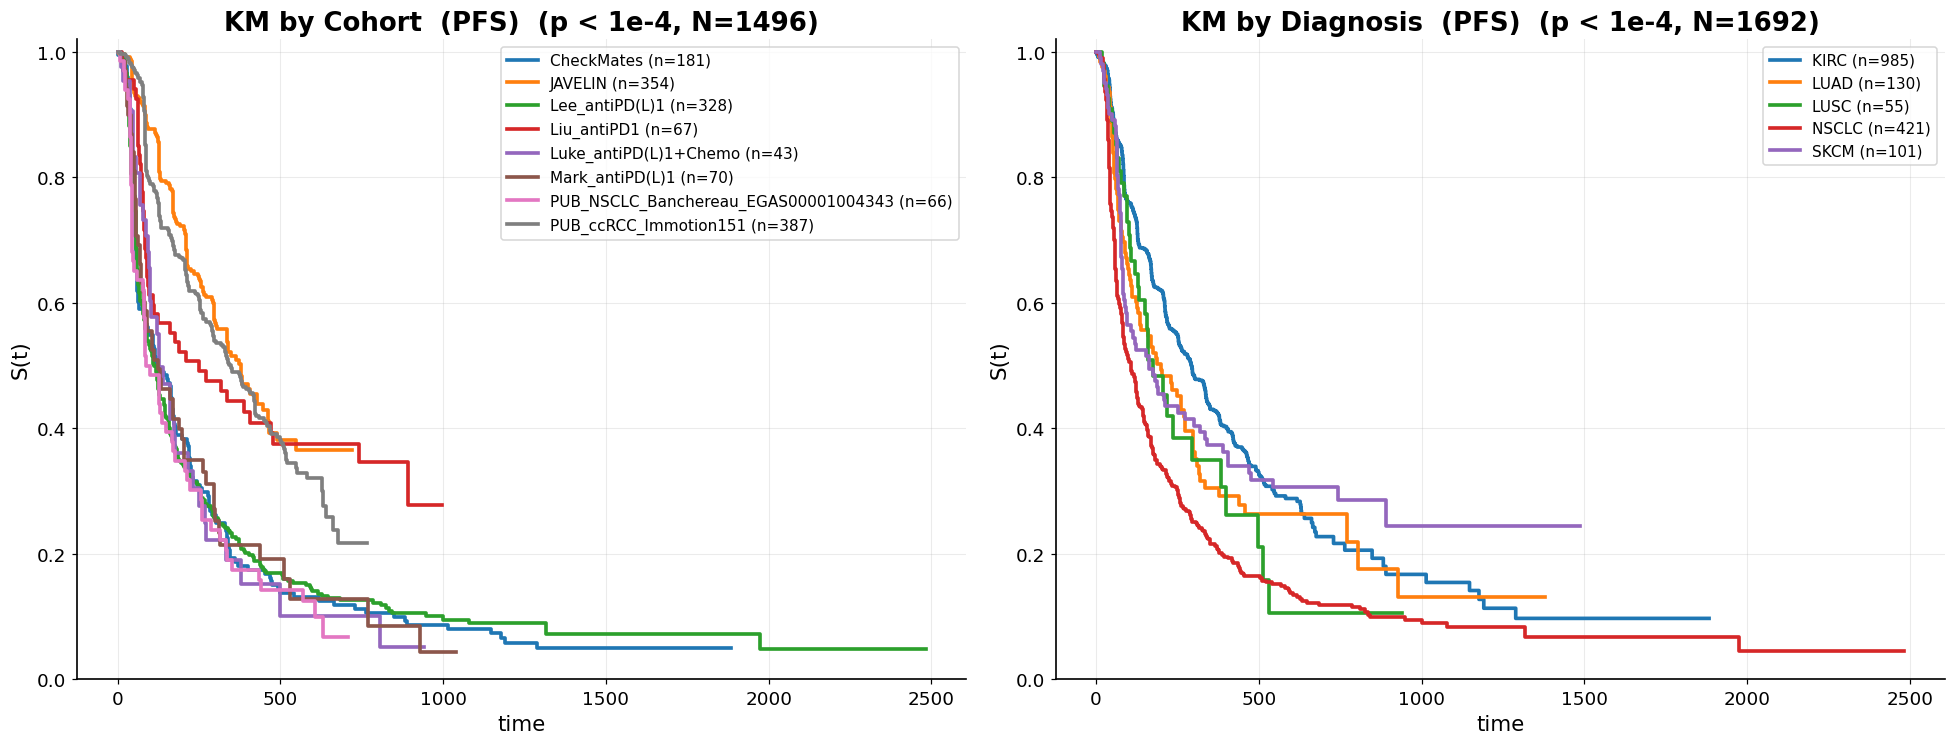

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
if t_col and e_col:
    t_arr = pd.to_numeric(train.obs[t_col], errors="coerce")
    e_arr = pd.to_numeric(train.obs[e_col], errors="coerce")
    if "Cohort" in train.obs.columns:
        km_panel(axes[0], t_arr, e_arr, train.obs["Cohort"], title=f"KM by Cohort  ({t_col})")
    diag_c = first_col(train.obs, ["Diagnosis", "Tumor_type"])
    if diag_c:
        km_panel(axes[1], t_arr, e_arr, train.obs[diag_c], title=f"KM by {diag_c}  ({t_col})")
fig.tight_layout()
plt.show()


### 4.2  KM stratified by Stage and by Therapy

Tumour stage is the gold-standard prognostic axis -- if the survival
curves don't separate by stage, the dataset is broken. Therapy tells
us how much of the survival gradient is driven by treatment choice.

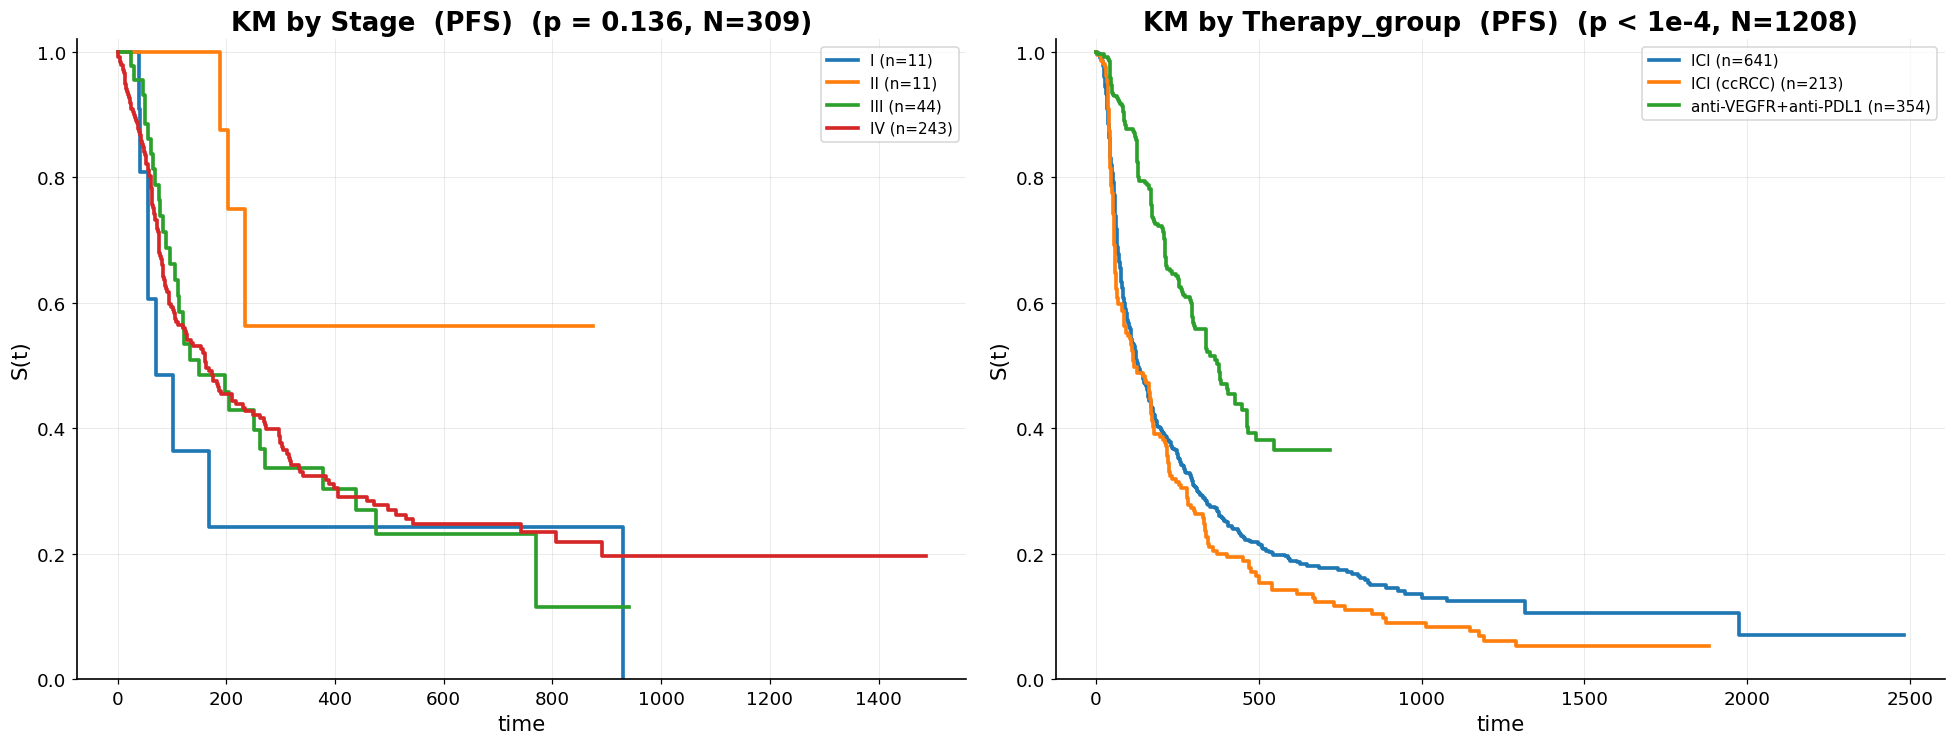

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
if t_col and e_col:
    t_arr = pd.to_numeric(train.obs[t_col], errors="coerce")
    e_arr = pd.to_numeric(train.obs[e_col], errors="coerce")
    stage_c = first_col(train.obs, ["Stage", "TumorStage", "STAGE"])
    if stage_c:
        km_panel(axes[0], t_arr, e_arr, train.obs[stage_c], title=f"KM by {stage_c}  ({t_col})")
    th_c = first_col(train.obs, ["Therapy_group", "Therapy", "treatment"])
    if th_c:
        km_panel(axes[1], t_arr, e_arr, train.obs[th_c], title=f"KM by {th_c}  ({t_col})")
fig.tight_layout()
plt.show()


## 5. Model interpretability -- SHAP + XGBoost gain

We train one XGBoost classifier on the (cAE + clinical) feature set
that the v4 leaderboard says is the best, then look at it from two
angles:

* **SHAP** answers "for THIS prediction, how much did each feature
  push the score up or down?" averaged across the cohort.
* **Gain** answers "across all decision splits in the trees, which
  features carry the most signal?"

The two should mostly agree on the top-10; where they disagree, the
disagreement itself is interesting.

In [12]:
"""Build the (cAE + clinical) fused matrix and train a stable XGBoost."""
from sklearn.preprocessing import StandardScaler
import xgboost as xgb

def build_fused_X():
    if CAE_KEY not in train.obsm:
        return None, None, None
    emb = np.asarray(train.obsm[CAE_KEY])
    base = pd.DataFrame(emb, columns=[f"cAE_{i}" for i in range(emb.shape[1])])
    clin_num_cols = [c for c in train.obs.columns
                     if c.startswith("Kassandra") or c.startswith("MFP")
                     or c in ("Age", "TMB", "PDL1")]
    clin = train.obs[clin_num_cols].apply(pd.to_numeric, errors="coerce").reset_index(drop=True)
    cat_cols = [c for c in ("Diagnosis", "Cohort", "Therapy_group", "Stage", "Gender")
                if c in train.obs.columns]
    cats = pd.get_dummies(train.obs[cat_cols].astype(str).reset_index(drop=True),
                          prefix=cat_cols, drop_first=False, dummy_na=False)
    X = pd.concat([base, clin, cats], axis=1)
    y_col = first_col(train.obs, ["Response_binary", "Response", "RECIST"])
    if y_col is None:
        return X, None, X.columns.tolist()
    yraw = train.obs[y_col].astype(str).str.upper()
    pos = {"R", "RESPONDER", "RESPONSE", "1", "TRUE", "Y", "YES", "CR", "PR"}
    y = yraw.isin(pos).astype(int).reset_index(drop=True).values
    X = X.fillna(X.median(numeric_only=True))
    return X, y, X.columns.tolist()

X, y, feat_names = build_fused_X()
xgb_model = None
if X is not None and y is not None and y.sum() > 5:
    Xs = StandardScaler().fit_transform(X.values)
    pos_w = float(((y == 0).sum() + 1) / (y.sum() + 1))
    xgb_model = xgb.XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.85, colsample_bytree=0.7,
        scale_pos_weight=pos_w, eval_metric="logloss",
        n_jobs=1, random_state=42, tree_method="hist",
    )
    xgb_model.fit(Xs, y)
    print(f"XGBoost trained on X={Xs.shape}, positive rate={y.mean():.3f}, "
          f"train AUC≈{xgb_model.score(Xs, y):.3f} (= accuracy)")
else:
    print("(X or y missing -- skipping XGB / SHAP)")


XGBoost trained on X=(2027, 601), positive rate=0.292, train AUC≈0.968 (= accuracy)


### 5.1  SHAP global -- beeswarm + bar (top-15 features)

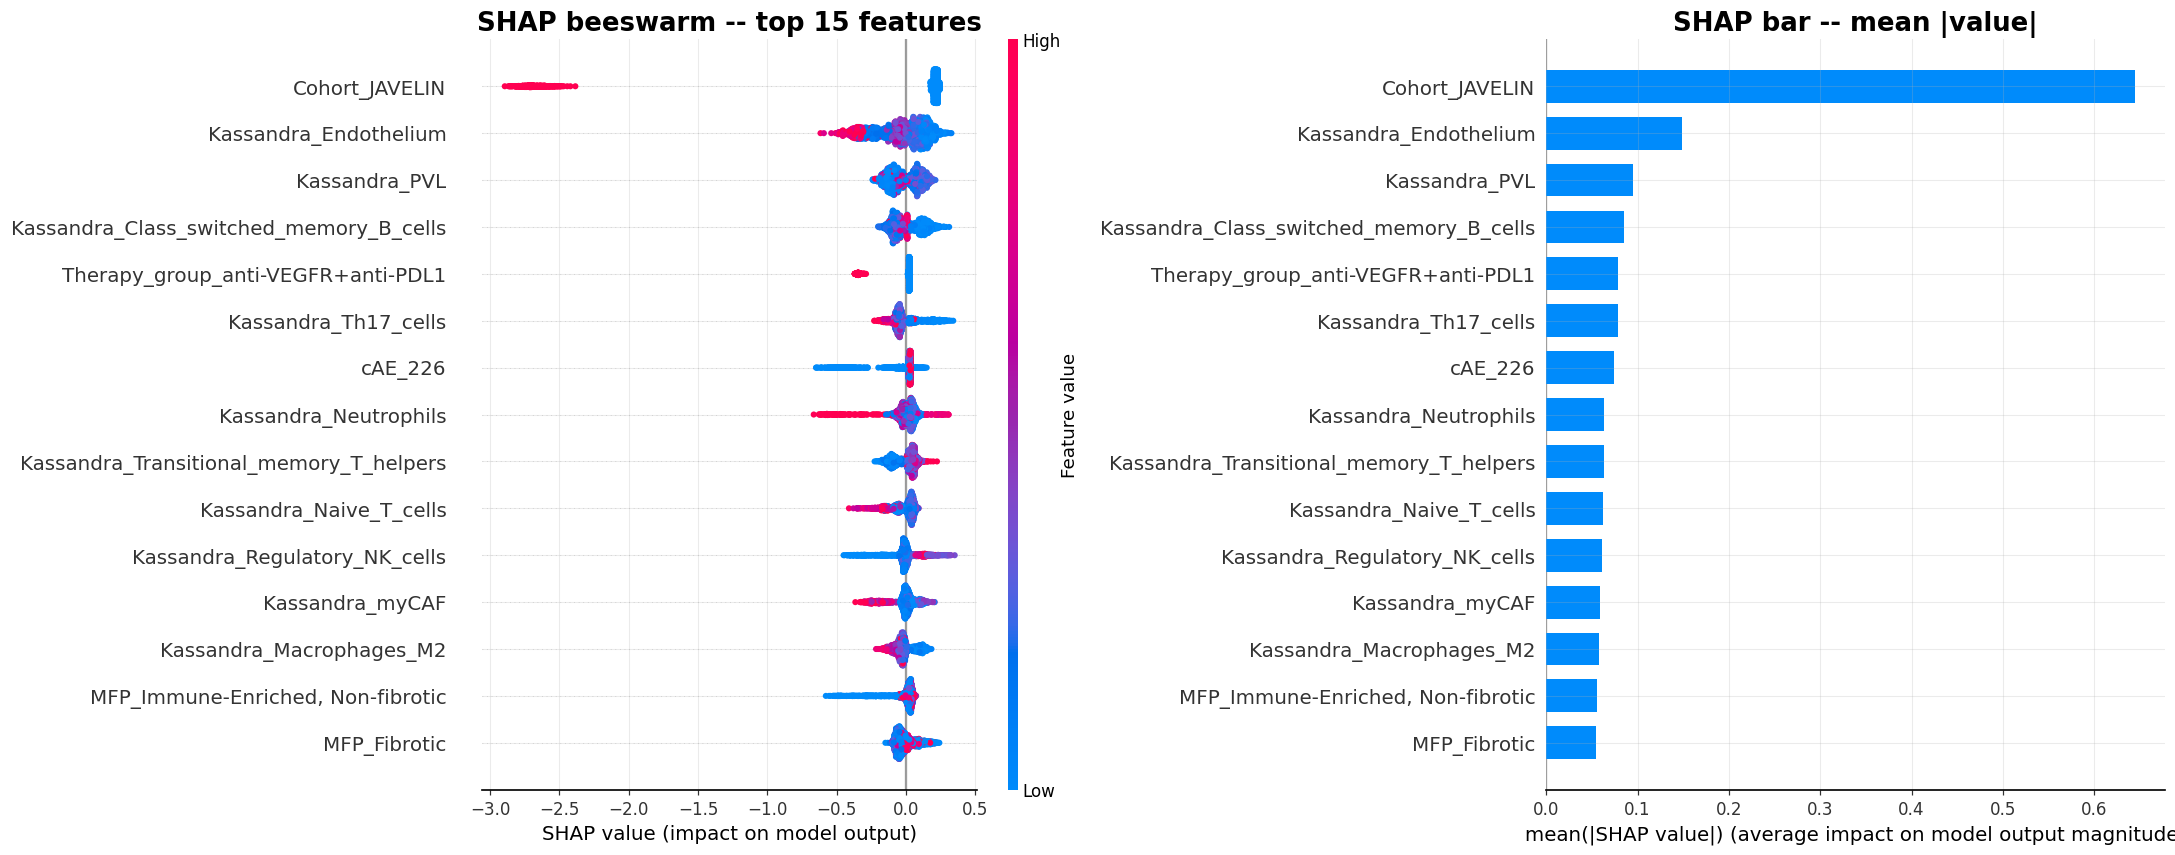

In [13]:
import shap

if xgb_model is not None:
    Xs = StandardScaler().fit_transform(X.values)
    explainer = shap.TreeExplainer(xgb_model)
    shap_values = explainer.shap_values(Xs)
    shap_df = pd.DataFrame(shap_values, columns=feat_names)
    abs_mean = shap_df.abs().mean().sort_values(ascending=False)
    top15 = abs_mean.head(15).index.tolist()

    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    plt.sca(axes[0])
    shap.summary_plot(shap_df[top15].values, X[top15],
                      feature_names=top15, show=False, plot_type="dot",
                      max_display=15, plot_size=None)
    axes[0].set_title("SHAP beeswarm -- top 15 features")

    plt.sca(axes[1])
    shap.summary_plot(shap_df[top15].values, X[top15],
                      feature_names=top15, show=False, plot_type="bar",
                      max_display=15, plot_size=None)
    axes[1].set_title("SHAP bar -- mean |value|")

    fig.tight_layout()
    plt.show()
else:
    print("(no model -- skipping)")


### 5.2  SHAP dependence -- top-3 Kassandra cell fractions

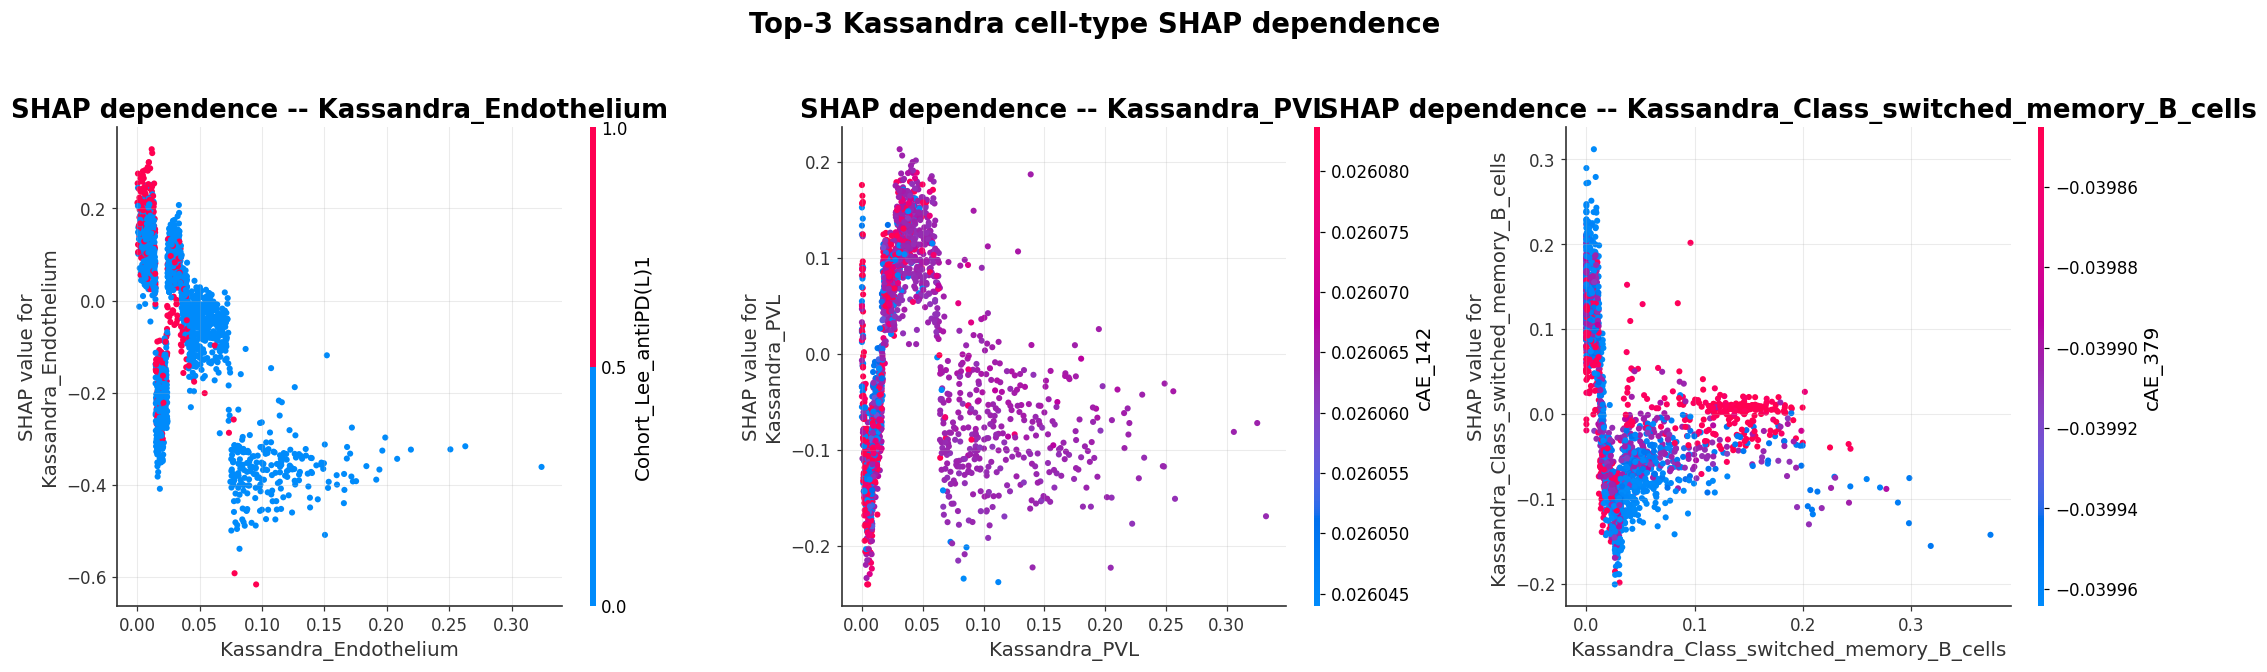

In [14]:
if xgb_model is not None:
    Xs = StandardScaler().fit_transform(X.values)
    explainer = shap.TreeExplainer(xgb_model)
    sv = explainer.shap_values(Xs)
    abs_mean = pd.Series(np.abs(sv).mean(axis=0), index=feat_names)
    kass_top3 = [c for c in abs_mean.sort_values(ascending=False).index
                 if c.startswith("Kassandra")][:3]
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    for ax, feat in zip(axes, kass_top3):
        plt.sca(ax)
        shap.dependence_plot(feat, sv, X, feature_names=feat_names,
                             interaction_index="auto", show=False, ax=ax)
        ax.set_title(f"SHAP dependence -- {feat}")
    fig.suptitle("Top-3 Kassandra cell-type SHAP dependence", fontsize=18, fontweight="bold", y=1.02)
    fig.tight_layout()
    plt.show()


### 5.3  XGBoost gain ranking (top-15)

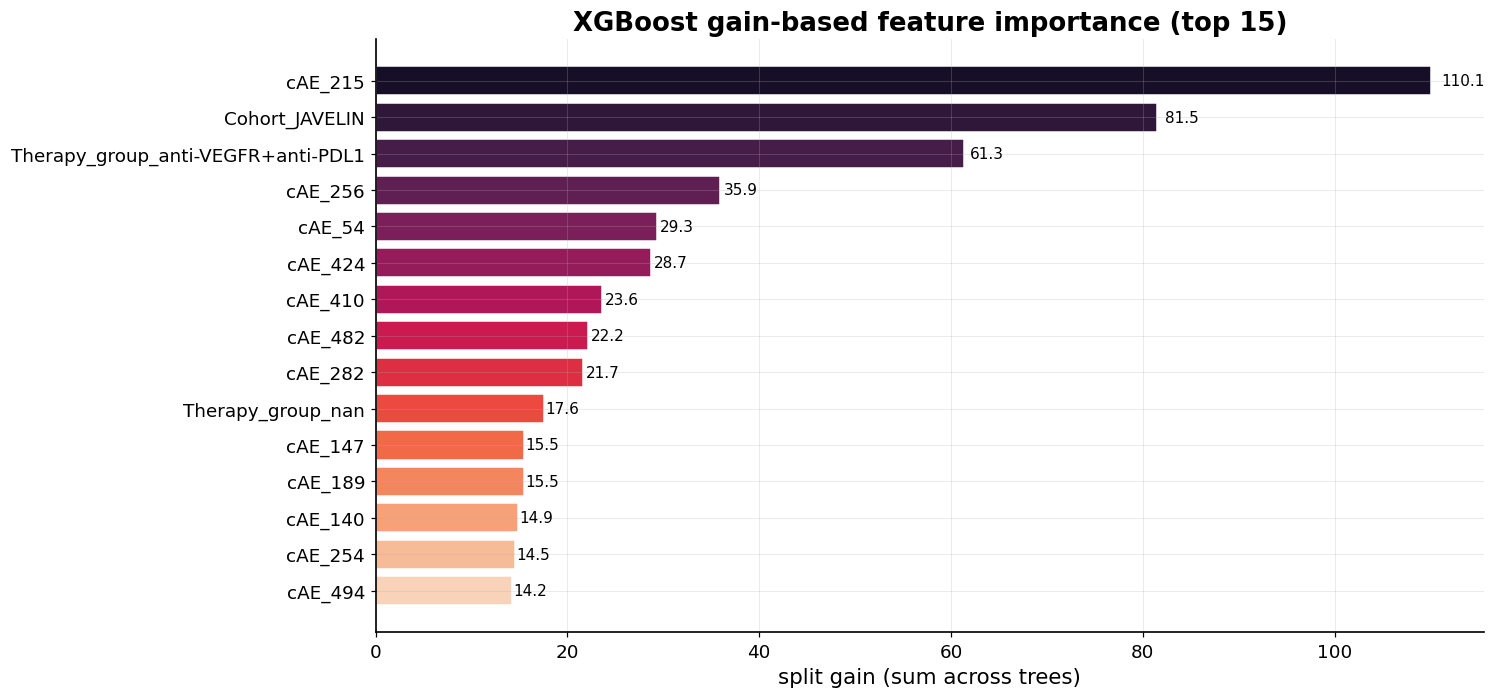

In [15]:
if xgb_model is not None:
    booster = xgb_model.get_booster()
    gain = booster.get_score(importance_type="gain")
    if gain:
        # XGBoost names features f0, f1, ...; map back to real names
        ranked = sorted(gain.items(), key=lambda kv: -kv[1])[:15]
        labels = [feat_names[int(k[1:])] if k.startswith("f") else k for k, _ in ranked]
        values = [v for _, v in ranked]
        fig, ax = plt.subplots(figsize=(13, 7))
        bars = ax.barh(labels[::-1], values[::-1],
                       color=sns.color_palette("rocket_r", len(values)),
                       edgecolor="white", linewidth=1.0)
        for b, v in zip(bars, values[::-1]):
            ax.text(v * 1.01, b.get_y() + b.get_height()/2,
                    f"{v:.1f}", va="center", fontsize=10)
        ax.set_title("XGBoost gain-based feature importance (top 15)")
        ax.set_xlabel("split gain (sum across trees)")
        plt.show()


## 6. Out-of-distribution generalization on PUB cohorts

We train ONE classifier on the TRAIN pool (cAE + clinical), then
score it cold on each public PUB cohort. ROC and PR are paired views;
PR is the more honest one when the positive class is rare.

In [16]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

def encode_pub(pub_ad, train_X_cols):
    if pub_ad is None or CAE_OOD_KEY not in pub_ad.obsm and CAE_KEY not in pub_ad.obsm:
        return None, None
    emb = np.asarray(pub_ad.obsm.get(CAE_OOD_KEY, pub_ad.obsm.get(CAE_KEY)))
    base = pd.DataFrame(emb, columns=[f"cAE_{i}" for i in range(emb.shape[1])])
    clin_num_cols = [c for c in pub_ad.obs.columns
                     if c.startswith("Kassandra") or c.startswith("MFP")
                     or c in ("Age", "TMB", "PDL1")]
    clin = pub_ad.obs[clin_num_cols].apply(pd.to_numeric, errors="coerce").reset_index(drop=True)
    cat_cols = [c for c in ("Diagnosis", "Cohort", "Therapy_group", "Stage", "Gender")
                if c in pub_ad.obs.columns]
    cats = pd.get_dummies(pub_ad.obs[cat_cols].astype(str).reset_index(drop=True),
                          prefix=cat_cols, drop_first=False, dummy_na=False)
    Xp = pd.concat([base, clin, cats], axis=1)
    Xp = Xp.reindex(columns=train_X_cols, fill_value=0)
    Xp = Xp.fillna(Xp.median(numeric_only=True)).fillna(0)

    y_col = first_col(pub_ad.obs, ["Response_binary", "Response", "RECIST"])
    if y_col is None:
        return Xp, None
    yraw = pub_ad.obs[y_col].astype(str).str.upper()
    pos = {"R", "RESPONDER", "RESPONSE", "1", "TRUE", "Y", "YES", "CR", "PR"}
    y = yraw.isin(pos).astype(int).reset_index(drop=True).values
    return Xp, y

ood_curves = []
if xgb_model is not None and X is not None:
    scaler = StandardScaler().fit(X.values)
    for name, ad in pubs.items():
        Xp, yp = encode_pub(ad, feat_names)
        if Xp is None or yp is None or yp.sum() < 3 or (1 - yp).sum() < 3:
            print(f"skip {name}: missing labels or too few cases")
            continue
        proba = xgb_model.predict_proba(scaler.transform(Xp.values))[:, 1]
        fpr, tpr, _ = roc_curve(yp, proba)
        prec, rec, _ = precision_recall_curve(yp, proba)
        ood_curves.append(dict(name=name, fpr=fpr, tpr=tpr, auc=auc(fpr, tpr),
                               prec=prec, rec=rec,
                               ap=average_precision_score(yp, proba),
                               n=len(yp), n_pos=int(yp.sum())))
print(f"computed {len(ood_curves)} OOD curve(s)")


computed 3 OOD curve(s)


### 6.1  ROC curves on each PUB cohort

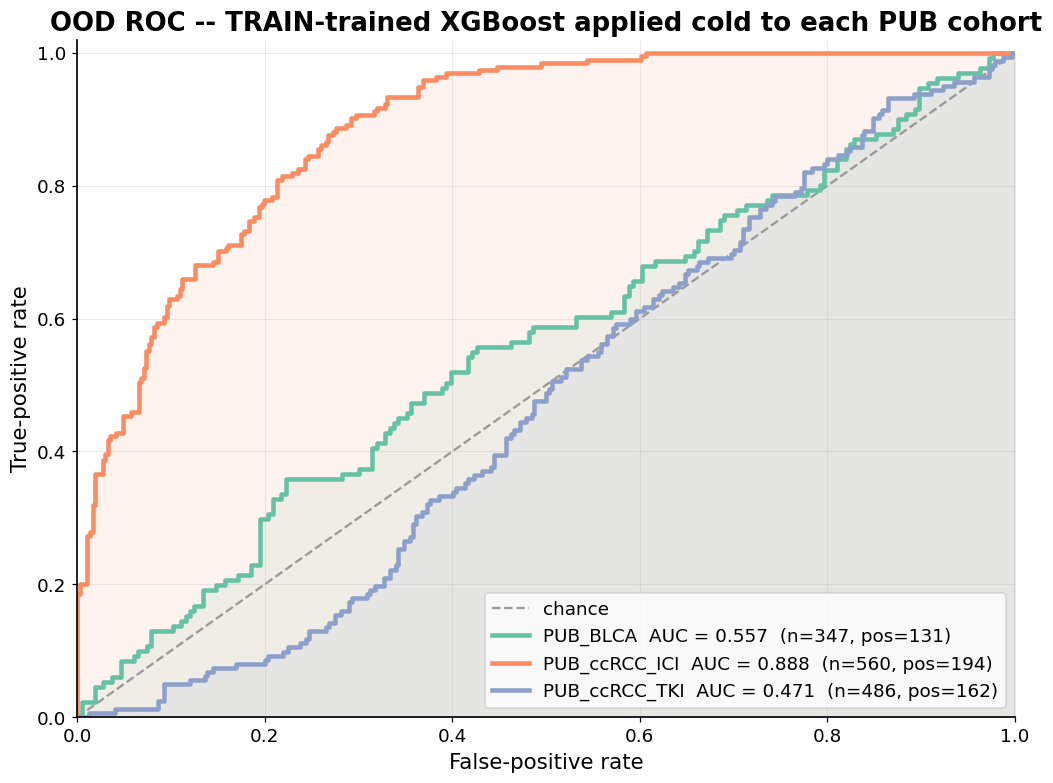

In [17]:
fig, ax = plt.subplots(figsize=(11, 8))
ax.plot([0, 1], [0, 1], ls="--", color="#999", lw=1.5, label="chance")
palette = sns.color_palette("Set2", len(ood_curves))
for c, color in zip(ood_curves, palette):
    ax.plot(c["fpr"], c["tpr"], lw=3, color=color,
            label=f"{c['name']}  AUC = {c['auc']:.3f}  (n={c['n']}, pos={c['n_pos']})")
    ax.fill_between(c["fpr"], 0, c["tpr"], color=color, alpha=0.10)
ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
ax.set_xlabel("False-positive rate"); ax.set_ylabel("True-positive rate")
ax.set_title("OOD ROC -- TRAIN-trained XGBoost applied cold to each PUB cohort")
ax.legend(frameon=True, loc="lower right")
plt.show()


### 6.2  Precision-Recall curves on each PUB cohort

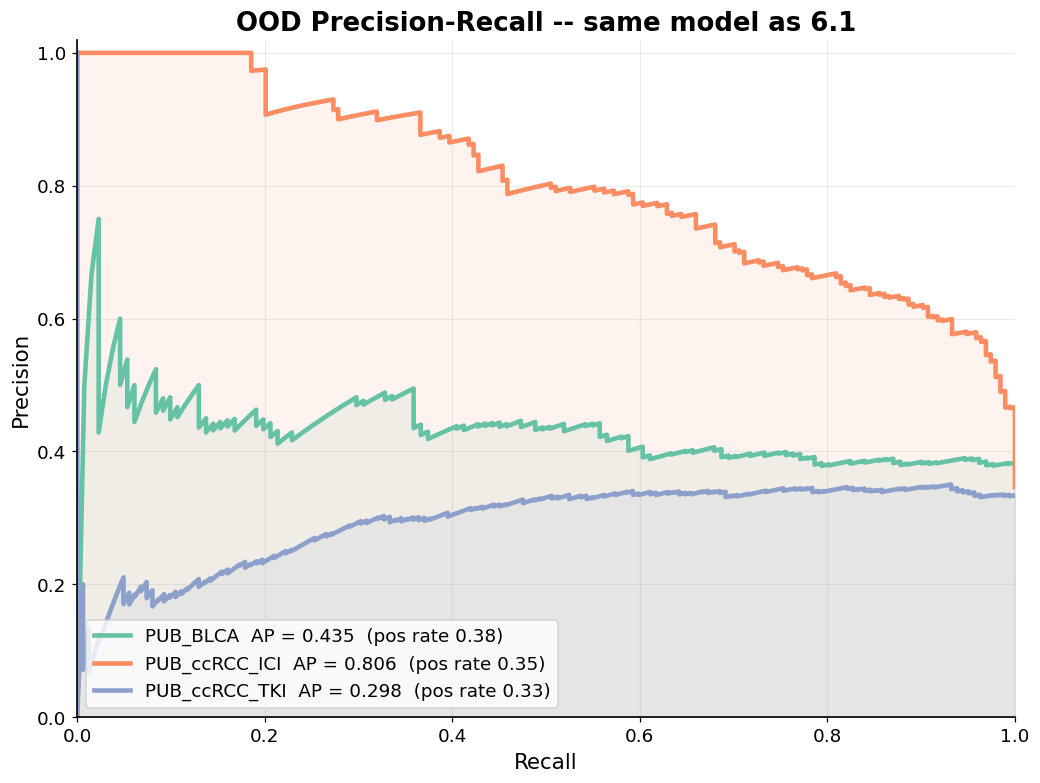

In [18]:
fig, ax = plt.subplots(figsize=(11, 8))
palette = sns.color_palette("Set2", len(ood_curves))
for c, color in zip(ood_curves, palette):
    ax.plot(c["rec"], c["prec"], lw=3, color=color,
            label=f"{c['name']}  AP = {c['ap']:.3f}  (pos rate {c['n_pos']/c['n']:.2f})")
    ax.fill_between(c["rec"], 0, c["prec"], color=color, alpha=0.10)
ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("OOD Precision-Recall -- same model as 6.1")
ax.legend(frameon=True, loc="lower left")
plt.show()


## 7. Leaderboard & diagnostics

Numbers, not paintings.

### 7.1  Best survival C-index per feature combination

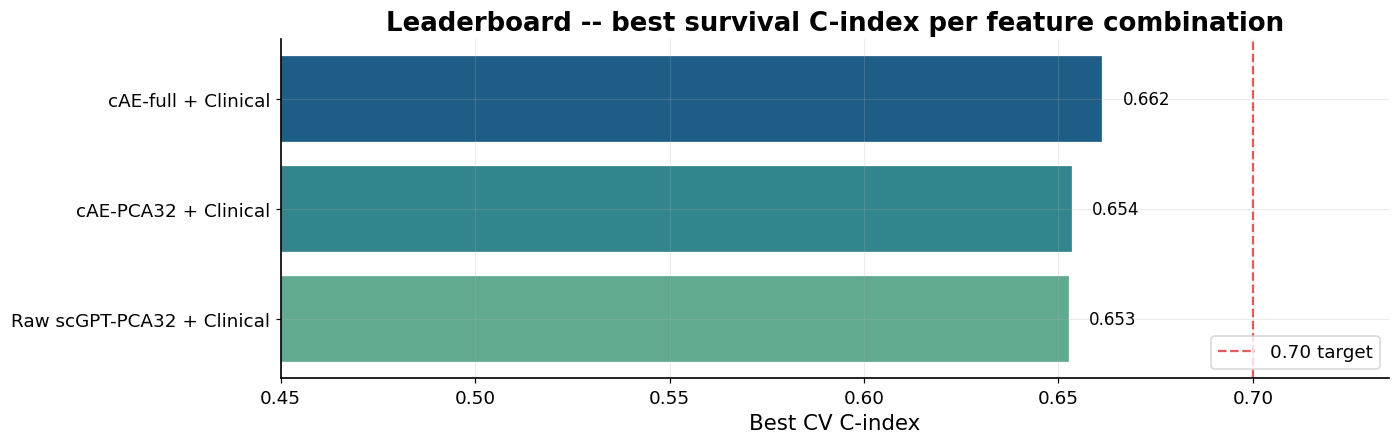

In [19]:
LB = METRICS_CSV / "v4_final_leaderboard.csv"
if LB.exists():
    df = pd.read_csv(LB)
    surv_col = first_col(df, ["Internal CV C-index", "Best survival C-index", "Best CV C-index"])
    label_col = first_col(df, ["Feature set", "Embedding", "feature_set", "Embedding type"])
    if surv_col and label_col:
        sub = df[[label_col, surv_col]].dropna().sort_values(surv_col)
        fig, ax = plt.subplots(figsize=(13, max(4, 0.55 * len(sub) + 2)))
        bars = ax.barh(sub[label_col].astype(str),
                       sub[surv_col].astype(float),
                       color=sns.color_palette("crest", len(sub)),
                       edgecolor="white", linewidth=1.5)
        ax.axvline(0.70, ls="--", color="#e53e3e", lw=1.5, alpha=0.85, label="0.70 target")
        for b, v in zip(bars, sub[surv_col].astype(float)):
            ax.text(v + 0.005, b.get_y() + b.get_height()/2,
                    f"{v:.3f}", va="center", fontsize=11)
        ax.set_xlim(left=min(0.45, sub[surv_col].min() - 0.02))
        ax.set_xlabel("Best CV C-index")
        ax.set_title("Leaderboard -- best survival C-index per feature combination")
        ax.legend(frameon=True, loc="lower right")
        plt.show()
    else:
        print("(leaderboard found but expected columns missing)")
else:
    print("(no leaderboard CSV yet -- run v4_definitive_pipeline first)")


### 7.2  Per-fold C-index spread by model and feature set

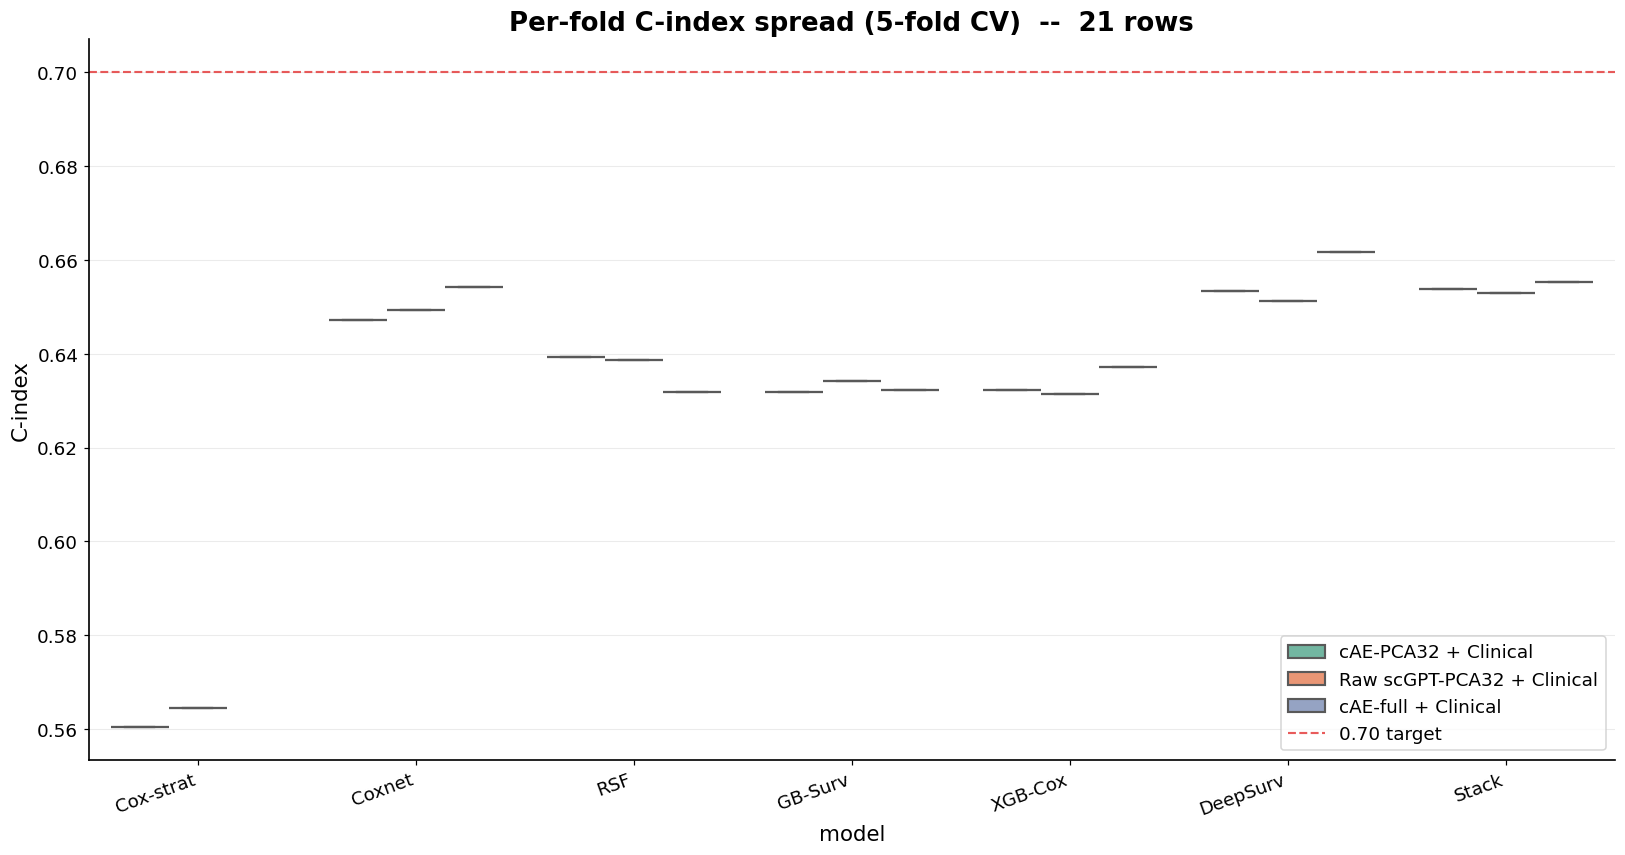

In [20]:
SR = METRICS_CSV / "v4_survival_results.csv"
if SR.exists():
    df = pd.read_csv(SR)
    cidx_col = first_col(df, ["c_index", "C-index", "C_index", "cindex", "value", "metric"])
    if cidx_col is None and any("cindex" in c.lower() for c in df.columns):
        cidx_col = next(c for c in df.columns if "cindex" in c.lower())
    if cidx_col:
        fig, ax = plt.subplots(figsize=(15, 8))
        sns.boxplot(
            data=df, x="model" if "model" in df.columns else df.columns[1],
            y=cidx_col,
            hue="embedding" if "embedding" in df.columns else (
                "feature_combination" if "feature_combination" in df.columns else None
            ),
            ax=ax, palette="Set2", linewidth=1.4,
        )
        ax.axhline(0.70, ls="--", color="#e53e3e", lw=1.4, alpha=0.85, label="0.70 target")
        ax.set_title(f"Per-fold C-index spread (5-fold CV)  --  {len(df):,} rows")
        ax.set_ylabel("C-index"); ax.set_xlabel("model")
        ax.legend(frameon=True, loc="lower right")
        plt.xticks(rotation=20, ha="right")
        plt.tight_layout(); plt.show()


### 7.3  UMAP coloured by predicted-risk tertile

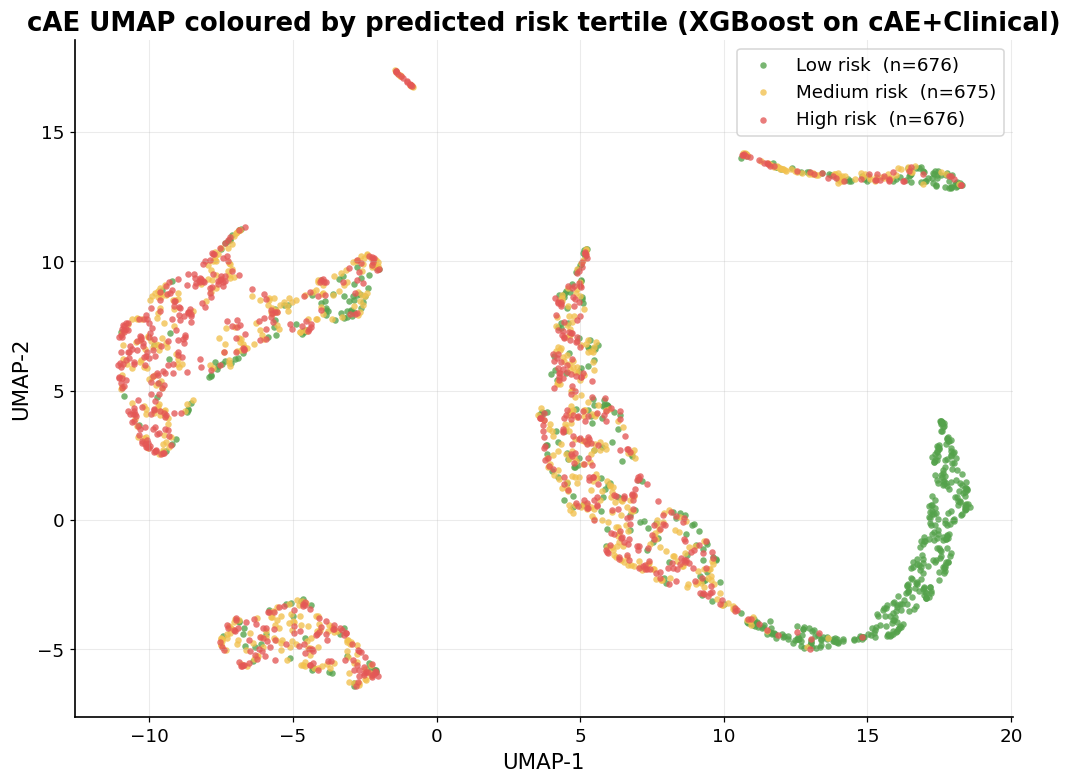

In [21]:
if xgb_model is not None and UMAP_CAE is not None:
    Xs = StandardScaler().fit_transform(X.values)
    risk = xgb_model.predict_proba(Xs)[:, 1]
    tert = pd.qcut(risk, q=3, labels=["Low risk", "Medium risk", "High risk"])
    fig, ax = plt.subplots(figsize=(11, 8))
    palette = ["#54A24B", "#F2C14E", "#E45756"]
    valid = ~np.isnan(UMAP_CAE).any(axis=1)
    for i, lvl in enumerate(["Low risk", "Medium risk", "High risk"]):
        m = np.asarray(tert == lvl) & valid
        ax.scatter(UMAP_CAE[m, 0], UMAP_CAE[m, 1],
                   c=[palette[i]], s=18, alpha=0.78,
                   label=f"{lvl}  (n={int(m.sum())})", linewidths=0)
    ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2")
    ax.set_title("cAE UMAP coloured by predicted risk tertile (XGBoost on cAE+Clinical)")
    ax.legend(frameon=True, loc="best")
    plt.show()


### 7.4  KM by predicted-risk tertile

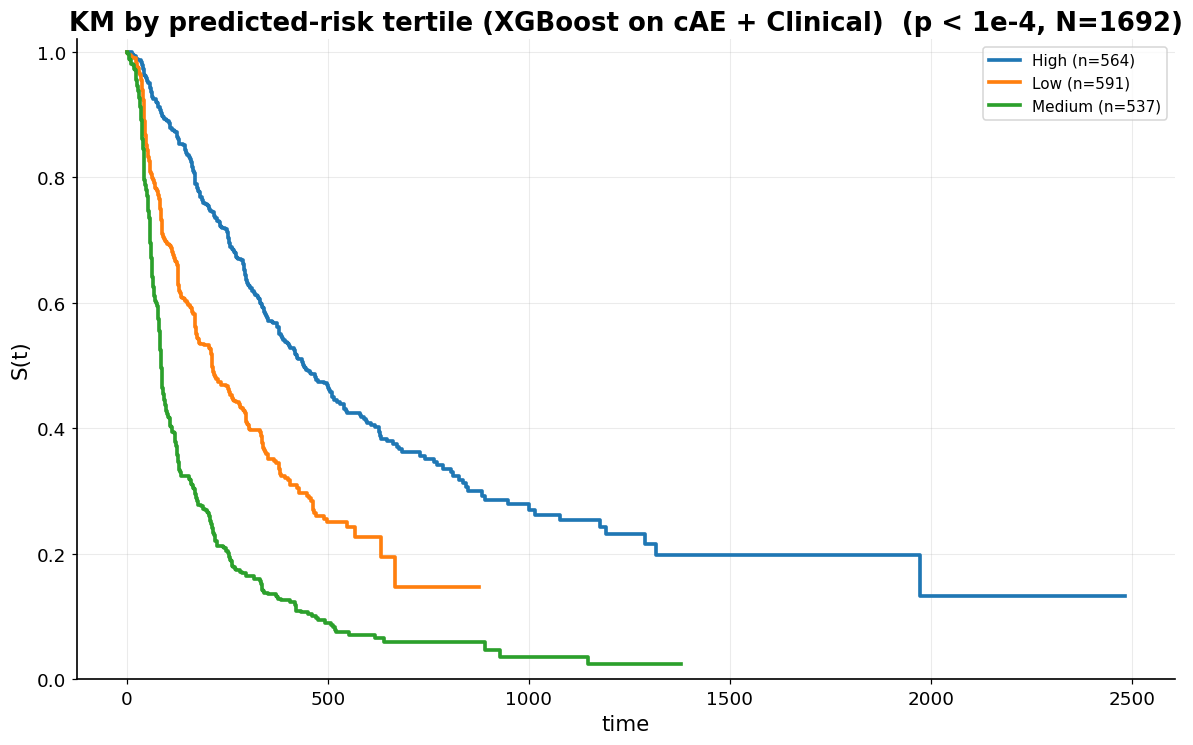

In [22]:
if xgb_model is not None and t_col and e_col:
    Xs = StandardScaler().fit_transform(X.values)
    risk = xgb_model.predict_proba(Xs)[:, 1]
    tert = pd.qcut(risk, q=3, labels=["Low", "Medium", "High"])
    fig, ax = plt.subplots(figsize=(11, 7))
    km_panel(ax,
             pd.to_numeric(train.obs[t_col], errors="coerce"),
             pd.to_numeric(train.obs[e_col], errors="coerce"),
             tert,
             title="KM by predicted-risk tertile (XGBoost on cAE + Clinical)")
    plt.tight_layout(); plt.show()


### 7.5  Confusion matrices grid (TRAIN OOF-style)

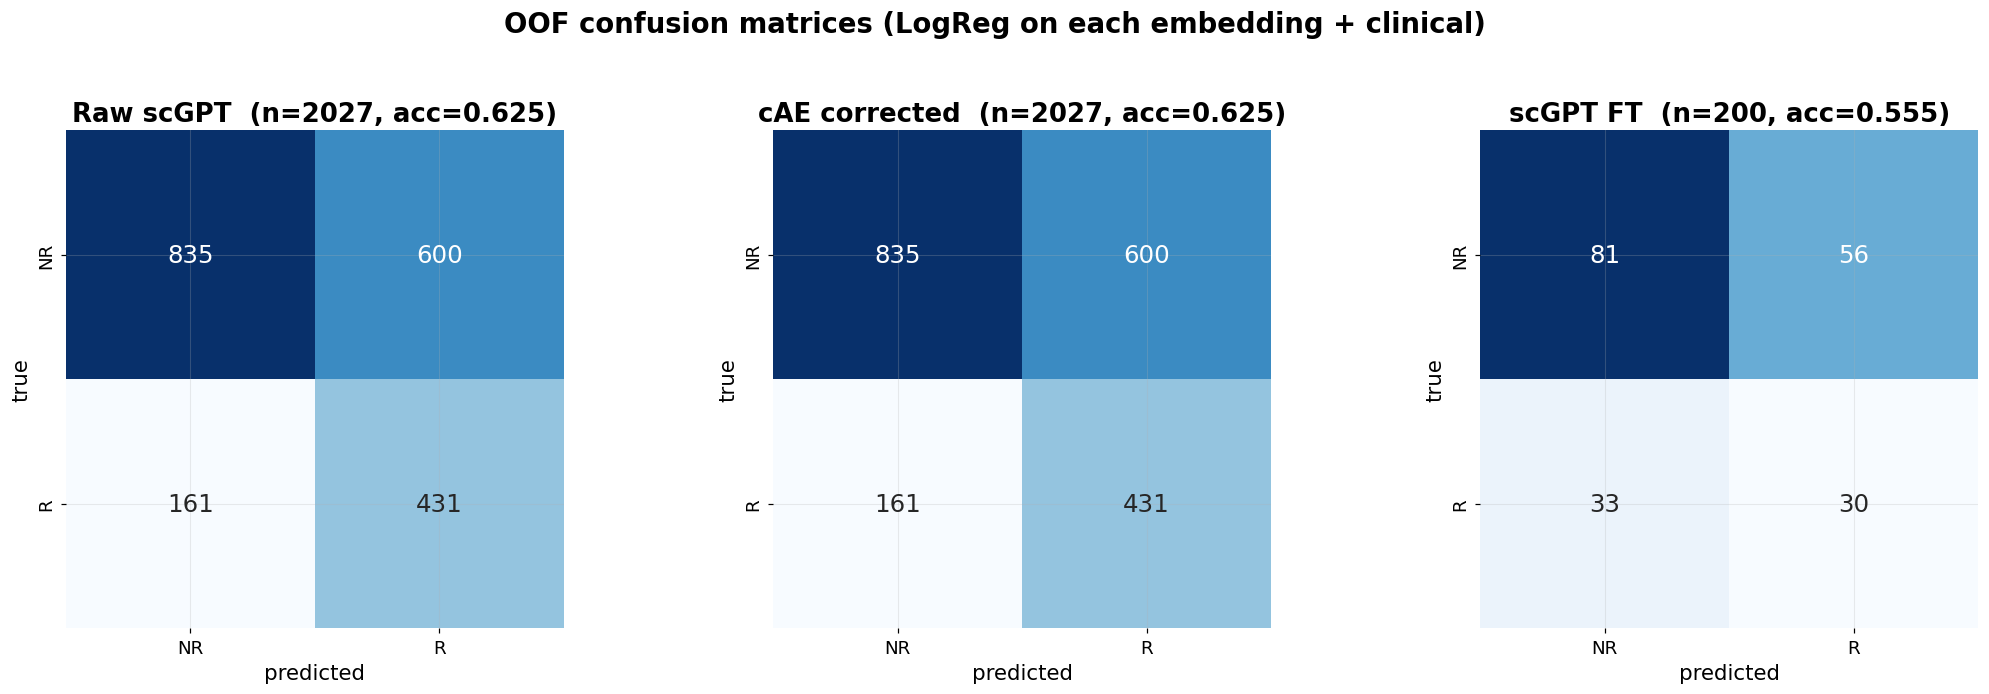

In [23]:
"""5-fold OOF confusion matrices for the best classifier per embedding."""
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

def oof_cm(emb_key):
    if emb_key not in train.obsm or X is None or y is None:
        return None
    emb = np.asarray(train.obsm[emb_key])
    valid = ~np.isnan(emb).any(axis=1)
    if valid.sum() < 50: return None
    Xv = X.loc[valid].values
    yv = y[valid]
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    pred = np.zeros_like(yv)
    for tr_idx, te_idx in skf.split(Xv, yv):
        sc = StandardScaler().fit(Xv[tr_idx])
        clf = LogisticRegression(max_iter=300, C=0.5, class_weight="balanced",
                                 random_state=42, n_jobs=1)
        clf.fit(sc.transform(Xv[tr_idx]), yv[tr_idx])
        pred[te_idx] = clf.predict(sc.transform(Xv[te_idx]))
    return confusion_matrix(yv, pred), int(valid.sum())

panels = []
for k, label in [(RAW_KEY, "Raw scGPT"), (CAE_KEY, "cAE corrected"), (FT_KEY, "scGPT FT")]:
    if k in train.obsm:
        res = oof_cm(k)
        if res is not None:
            panels.append((label, res[0], res[1]))

if panels:
    fig, axes = plt.subplots(1, len(panels), figsize=(6.5 * len(panels), 6))
    axes = np.atleast_1d(axes)
    for ax, (label, cm, n) in zip(axes, panels):
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                    cbar=False, square=True, annot_kws={"fontsize": 16},
                    xticklabels=["NR", "R"], yticklabels=["NR", "R"])
        acc = cm.trace() / cm.sum()
        ax.set_xlabel("predicted"); ax.set_ylabel("true")
        ax.set_title(f"{label}  (n={n}, acc={acc:.3f})")
    fig.suptitle("OOF confusion matrices (LogReg on each embedding + clinical)",
                 fontsize=18, fontweight="bold", y=1.04)
    fig.tight_layout(); plt.show()


## End

If a section above is empty, the corresponding artifact (e.g. SFT
embeddings, Response labels, or v4 metrics CSV) was not on disk when
the notebook ran -- re-execute after running the SFT and v4 pipelines.